# Combined Filter

Loads processed outputs from `mems_filter.ipynb` and `spec_filter.ipynb` and merges them into one DataFrame per sub-dataset.

**Run both source notebooks first** (execute their export cells) before running this notebook.

Each sub-dataset combines:
- **MEMS channels**: VOC, NH3, HCHO (drift-corrected, EMA-filtered)
- **SPEC channels**: H2S ppm, EtOH ppm (offset-corrected, two-stage filtered)
- **ENV channels**: temp_C, rh_pct

In [94]:
import os
import matplotlib.pyplot as plt
import pandas as pd

PROCESSED = "processed"

MEMS = ["voc", "nh3", "hcho"]
SPEC = ["h2s_ppm", "etoh_ppm"]
ENV  = ["temp_C", "rh_pct"]
ALL_CHANNELS = MEMS + SPEC + ENV

# ── Auto-discover and load all processed pickles ──────────────────────────────
def _load_pickles(prefix):
    result = {}
    for fname in sorted(os.listdir(PROCESSED)):
        if fname.startswith(prefix) and fname.endswith(".pkl"):
            key = fname[len(prefix):-4]   # strip prefix and .pkl extension
            result[key] = pd.read_pickle(os.path.join(PROCESSED, fname))
    return result

mems = _load_pickles("mems_")
spec = _load_pickles("spec_")

print(f"MEMS pickles loaded ({len(mems)}):")
for k, df in mems.items():
    print(f"  {k:<12}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")

print(f"\nSPEC pickles loaded ({len(spec)}):")
for k, df in spec.items():
    print(f"  {k:<12}  {len(df):5} rows  elapsed {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f} s  cols: {list(df.columns)}")

mems_only = set(mems) - set(spec)
spec_only = set(spec) - set(mems)
if mems_only:
    print(f"\nWARNING: in MEMS but missing SPEC pickle: {sorted(mems_only)}")
if spec_only:
    print(f"\nWARNING: in SPEC but missing MEMS pickle: {sorted(spec_only)}")

MEMS pickles loaded (18):
  blood_0        3666 rows  elapsed 0–3753 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_1        1908 rows  elapsed 1751–3703 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_2        2882 rows  elapsed 0–2987 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_3        3324 rows  elapsed 0–3484 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_4        2357 rows  elapsed 0–2473 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_5        3598 rows  elapsed 0–3746 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_6        3383 rows  elapsed 500–3963 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_7        3486 rows  elapsed 0–3568 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_pct']
  blood_8        3216 rows  elapsed 501–3791 s  cols: ['elapsed_s', 'voc', 'nh3', 'hcho', 'temp_C', 'rh_p

## Merge

MEMS and SPEC data come from the same CSV recorded at 1 Hz, so `elapsed_s` should align exactly. The merge checks this explicitly:

1. **Exact match** — merge on `elapsed_s` directly; if every row matches, use as-is.
2. **Nearest-match fallback** — if any rows are unmatched (floating-point drift or minor resampling difference), `merge_asof` within `MERGE_TOL` seconds is used instead. Rows outside the tolerance are dropped and reported.

Each merged dataset gets a `session` column (e.g. `"sweat_2"`) so that downstream train/validate/test splits can group by session.

In [96]:
MERGE_TOL = 0.5  # seconds — tolerance for nearest-match fallback

datasets = {}

print(f"{'Dataset':<12}  {'MEMS':>6}  {'SPEC':>6}  {'Merged':>7}  {'Dropped':>8}  {'Method'}")
print("-" * 58)

for key in sorted(mems):
    if key not in spec:
        print(f"{key:<12}  -- no SPEC pickle, skipped --")
        continue

    m = mems[key]
    s = spec[key]

    # Exact merge on elapsed_s
    exact = pd.merge(
        m,
        s[["elapsed_s"] + SPEC],
        on="elapsed_s",
        how="inner",
    )
    n_exact_dropped = max(len(m), len(s)) - len(exact)

    if n_exact_dropped == 0:
        merged = exact
        method = "exact"
    else:
        # Nearest-match fallback — sorts required by merge_asof
        m_s = m.sort_values("elapsed_s").reset_index(drop=True)
        s_s = s[["elapsed_s"] + SPEC].sort_values("elapsed_s").reset_index(drop=True)
        merged = pd.merge_asof(
            m_s, s_s,
            on="elapsed_s",
            tolerance=MERGE_TOL,
            direction="nearest",
        )
        merged = merged.dropna(subset=SPEC).reset_index(drop=True)
        method = f"nearest (tol={MERGE_TOL}s)"

    n_dropped = max(len(m), len(s)) - len(merged)
    flag = "  *** ROWS DROPPED ***" if n_dropped > 0 else ""

    merged = merged[["elapsed_s"] + ALL_CHANNELS].reset_index(drop=True)
    merged["session"] = key
    datasets[key] = merged

    print(f"{key:<12}  {len(m):>6}  {len(s):>6}  {len(merged):>7}  {n_dropped:>8}  {method}{flag}")

print(f"\nTotal sessions merged: {len(datasets)}")

Dataset         MEMS    SPEC   Merged   Dropped  Method
----------------------------------------------------------
blood_0         3666    3666     3666         0  exact
blood_1         1908    1908     1908         0  exact
blood_2         2882    2882     2882         0  exact
blood_3         3324    3324     3324         0  exact
blood_4         2357    2357     2357         0  exact
blood_5         3598    3598     3598         0  exact
blood_6         3383    3383     3383         0  exact
blood_7         3486    3486     3486         0  exact
blood_8         3216    3216     3216         0  exact
blood_9         4093    4093     4093         0  exact
sweat_1a        3909    3909     3909         0  exact
sweat_1b        2390    2390     2390         0  exact
sweat_2         5393    5393     5393         0  exact
sweat_3         5106    5106     5106         0  exact
sweat_4         4930    4930     4930         0  exact
sweat_5         2723    2723     2723         0  exact
sweat

## Channel Verification

In [97]:
for key, df in datasets.items():
    print(f"\n{key}")
    print(f"  {'Channel':<12} {'min':>10} {'max':>10} {'nulls':>8}")
    print(f"  {'-'*44}")
    for col in ALL_CHANNELS:
        null_count = df[col].isna().sum()
        print(f"  {col:<12} {df[col].min():>10.4f} {df[col].max():>10.4f} {null_count:>8}")



blood_0
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.4240        0
  nh3              0.0000     0.1873        0
  hcho             0.0000     0.4612        0
  h2s_ppm          0.0000     0.1261        0
  etoh_ppm         0.0000     3.2131        0
  temp_C          20.5000    21.7000        0
  rh_pct          26.7000    50.1000        0

blood_1
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.2372        0
  nh3              0.0000     0.2181        0
  hcho             0.0000     0.4332        0
  h2s_ppm          0.0000     0.1543        0
  etoh_ppm         0.0000     3.4523        0
  temp_C          20.2000    20.4000        0
  rh_pct          30.6000    46.9000        0

blood_2
  Channel             min        max    nulls
  --------------------------------------------
  voc              0.0000     0.1875        0
  nh

## Data Labelling

Each row is assigned one of three labels based on the time the sample was physically present in the sensor chamber:

| Label | Value | Meaning |
|-------|-------|---------|
| `baseline` | 0 | No sample present — sensor warming up or idle |
| `sweat`    | 1 | Sweat sample in chamber |
| `blood`    | 2 | Blood sample in chamber |

Sample windows run from the **sample introduction event** to the end of the session. `t_end=None` means end of the recording.

| Dataset  | Event (s) | t_start | t_end | Label |
|----------|-----------|---------|-------|-------|
| sweat_1a | 2950 | 2950 | 4000 | sweat |
| sweat_1b | 600  | 600  | 2446 | sweat |
| sweat_2  | 4250 | 4250 | 5521 | sweat |
| sweat_3  | 3550 | 3550 | 5227 | sweat |
| sweat_4  | 3900 | 3900 | 5042 | sweat |
| sweat_5  | 1250 | 1250 | 2786 | sweat |
| sweat_6  | 4700 | 4700 | 6133 | sweat |
| sweat_7  | 1750 | 1750 | 3659 | sweat |
| blood_0  | 1900 | 1900 | 3753 | blood |
| blood_1  | 2450 | 2450 | 3703 | blood |
| blood_2  | 1800 | 1800 | 2987 | blood |
| blood_3  | 2000 | 2000 | 3484 | blood |
| blood_4  | 1400 | 1400 | 2473 | blood |
| blood_5  | 1750 | 1750 | 3746 | blood |
| blood_6  | 2700 | 2700 | 3963 | blood |
| blood_7  | 2200 | 2200 | 3568 | blood |
| blood_8  | 2450 | 2450 | 3791 | blood |
| blood_9  | 2300 | 2300 | 4190 | blood |

Adjust any window boundaries above after reviewing the plots below.

In [ ]:
LABEL_BASELINE = 0
LABEL_SWEAT    = 1
LABEL_BLOOD    = 2

# (t_start, t_end, label) — t_end=None means end of session
SAMPLE_WINDOWS = {
    "sweat_1a": [(2870, 4000, LABEL_SWEAT)],
    "sweat_1b": [(570 , 2446, LABEL_SWEAT)],
    "sweat_2":  [(4230, 5521, LABEL_SWEAT)],
    "sweat_3":  [(3550, 5227, LABEL_SWEAT)],
    "sweat_4":  [(3860, 5042, LABEL_SWEAT)],
    "sweat_5":  [(1140, 2786, LABEL_SWEAT)],
    "sweat_6":  [(4600, 6133, LABEL_SWEAT)],
    "sweat_7":  [(1750, 3659, LABEL_SWEAT)],
    "blood_0":  [(1900, 3753, LABEL_BLOOD)],
    "blood_1":  [(2440, 3703, LABEL_BLOOD)],
    "blood_2":  [(1770, 2987, LABEL_BLOOD)],
    "blood_3":  [(1950, 3484, LABEL_BLOOD)],
    "blood_4":  [(1360, 2473, LABEL_BLOOD)],
    "blood_5":  [(1750, 3746, LABEL_BLOOD)],
    "blood_6":  [(2650, 3963, LABEL_BLOOD)],
    "blood_7":  [(2150, 3568, LABEL_BLOOD)],
    "blood_8":  [(2440, 3791, LABEL_BLOOD)],
    "blood_9":  [(2300, 4190, LABEL_BLOOD)],
}

for key, df in datasets.items():
    datasets[key] = df.copy()
    datasets[key]["label"] = LABEL_BASELINE
    for t_start, t_end, lbl in SAMPLE_WINDOWS.get(key, []):
        t = df["elapsed_s"]
        mask = (t >= t_start) & (t <= t_end)
        datasets[key].loc[mask, "label"] = lbl

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Dataset':<12}  {'baseline':>10}  {'sweat':>8}  {'blood':>8}  {'total':>8}  {'sample %':>9}")
print("-" * 64)
for key, df in sorted(datasets.items()):
    b  = (df["label"] == LABEL_BASELINE).sum()
    sw = (df["label"] == LABEL_SWEAT).sum()
    bl = (df["label"] == LABEL_BLOOD).sum()
    sample_pct = 100 * (sw + bl) / len(df)
    print(f"{key:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(df):>8}  {sample_pct:>8.1f}%")

Dataset         baseline     sweat     blood     total   sample %
----------------------------------------------------------------
blood_0             1856         0      1810      3666      49.4%
blood_1              675         0      1233      1908      64.6%
blood_2             1697         0      1185      2882      41.1%
blood_3             1860         0      1464      3324      44.0%
blood_4             1239         0      1118      2357      47.4%
blood_5             1690         0      1908      3598      53.0%
blood_6             2101         0      1282      3383      37.9%
blood_7             2101         0      1385      3486      39.7%
blood_8             1906         0      1310      3216      40.7%
blood_9             2247         0      1846      4093      45.1%
sweat_1a            2805      1104         0      3909      28.2%
sweat_1b             558      1832         0      2390      76.7%
sweat_2             4142      1251         0      5393      23.2%
sweat_3    

### Label Visualization

Shaded regions show the labelled time windows — **grey** = baseline, **green** = sweat, **red** = blood.

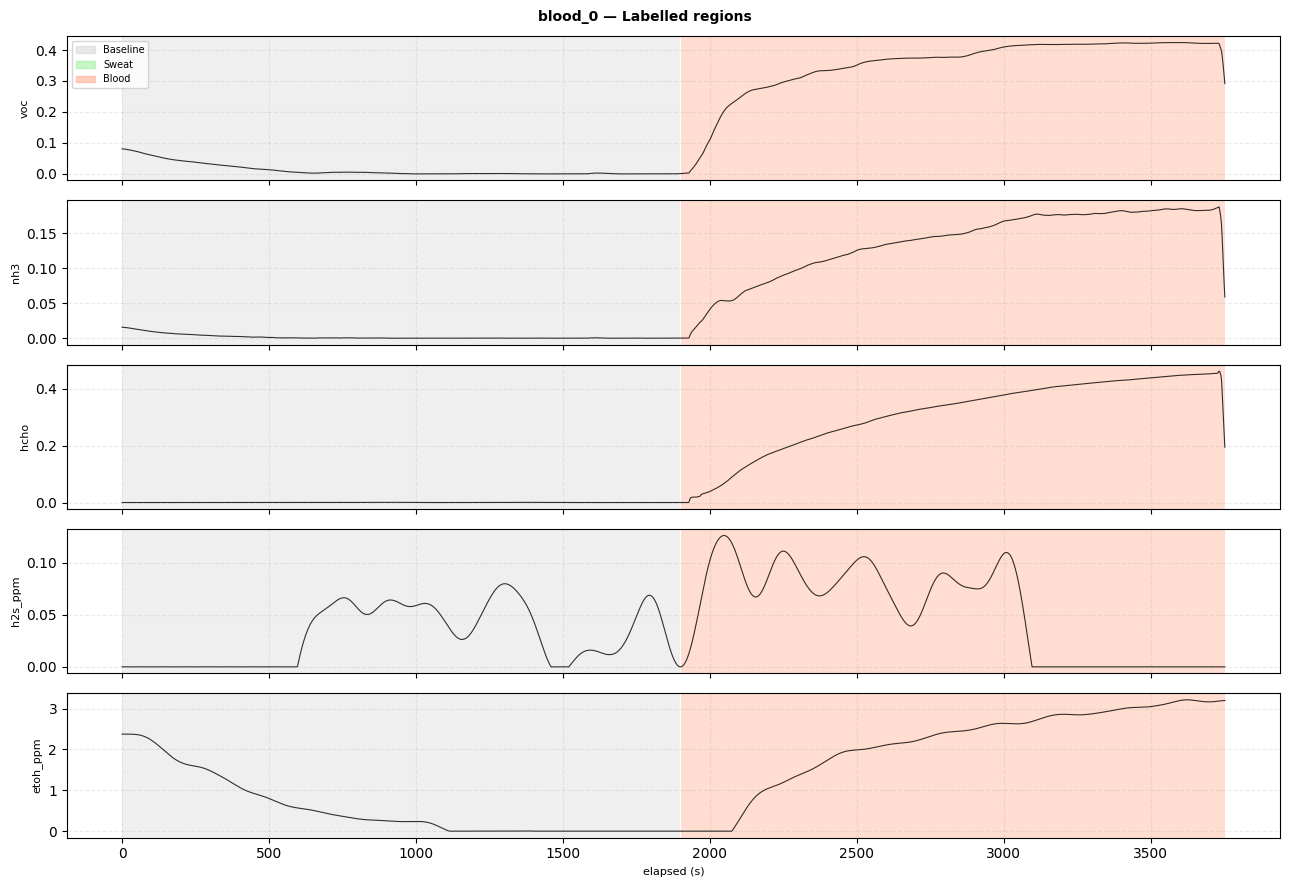

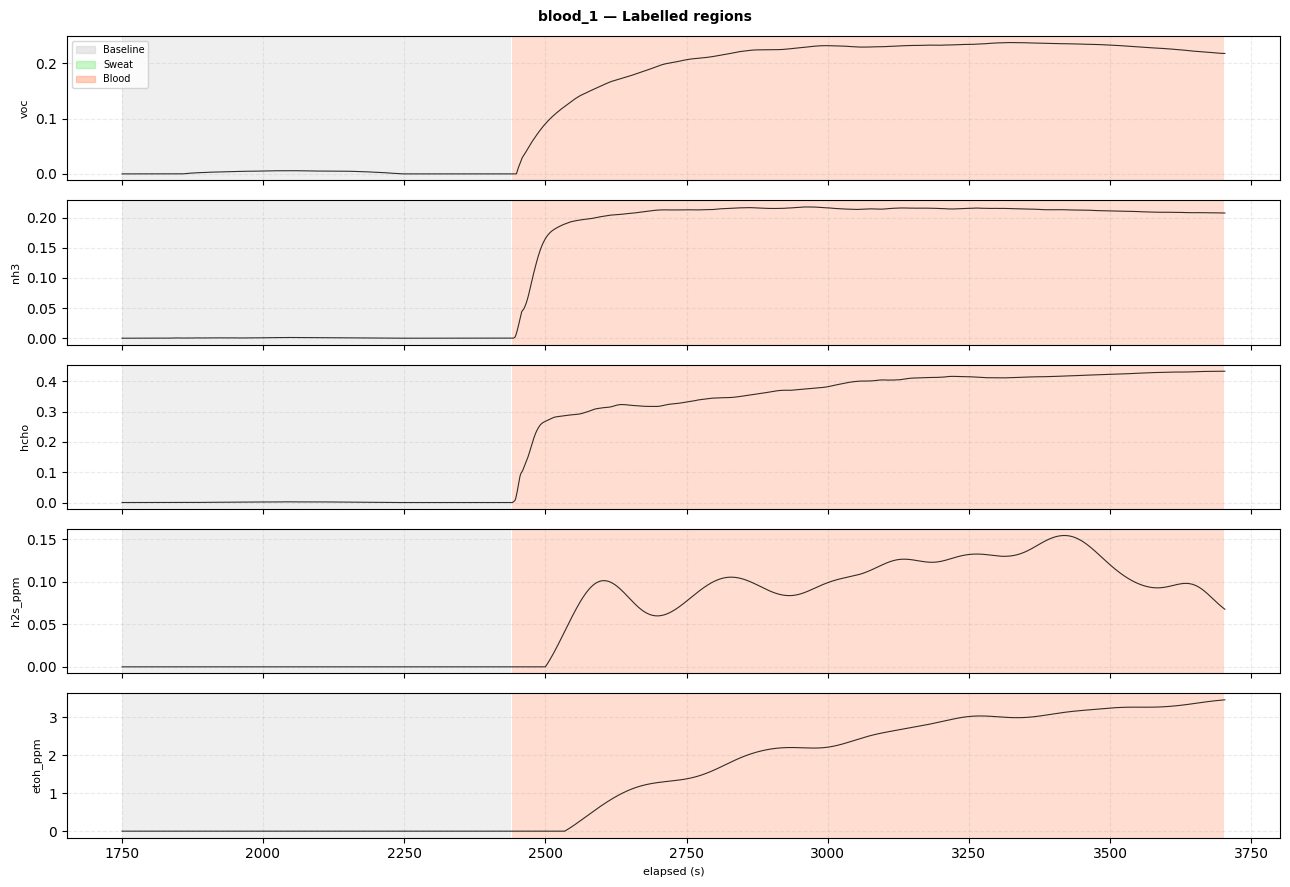

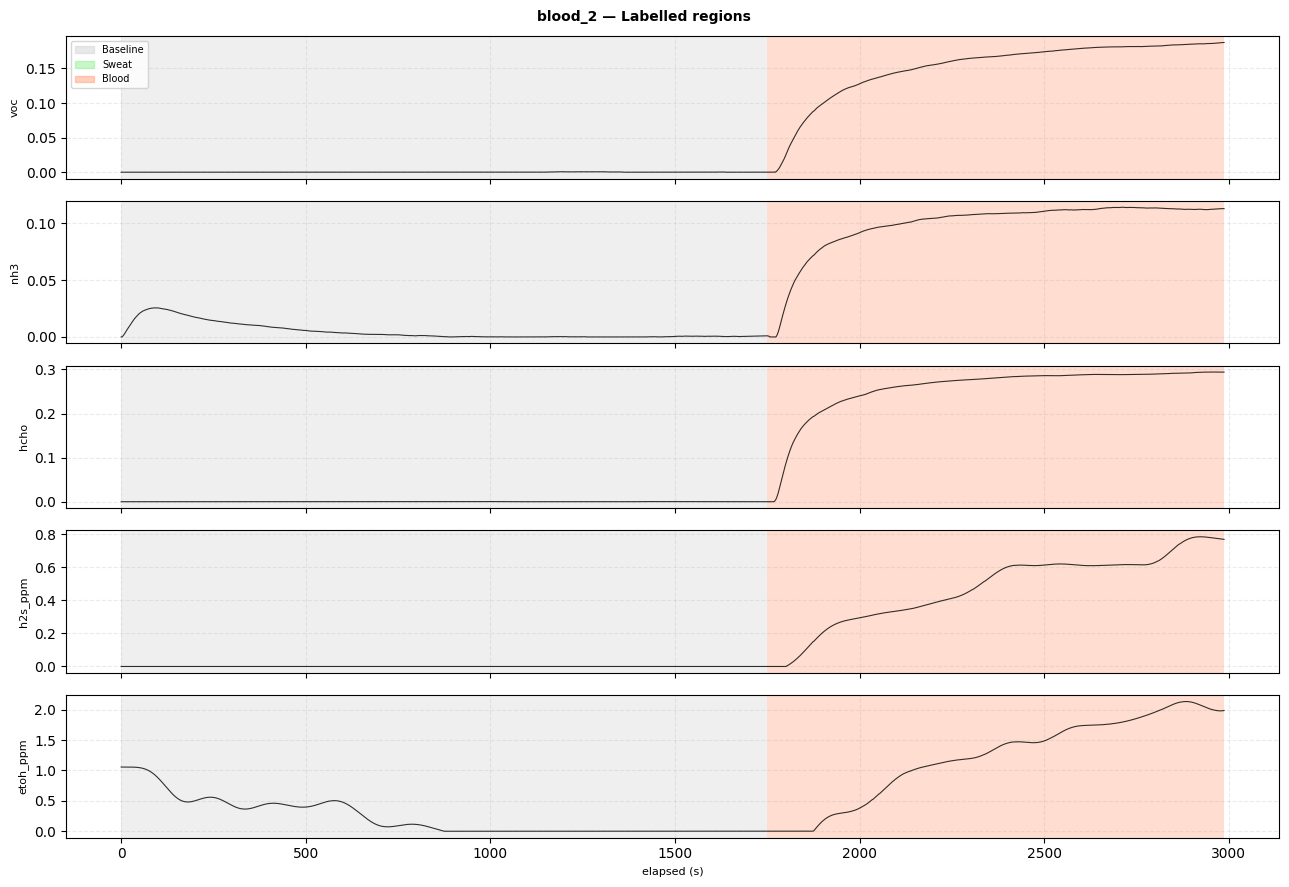

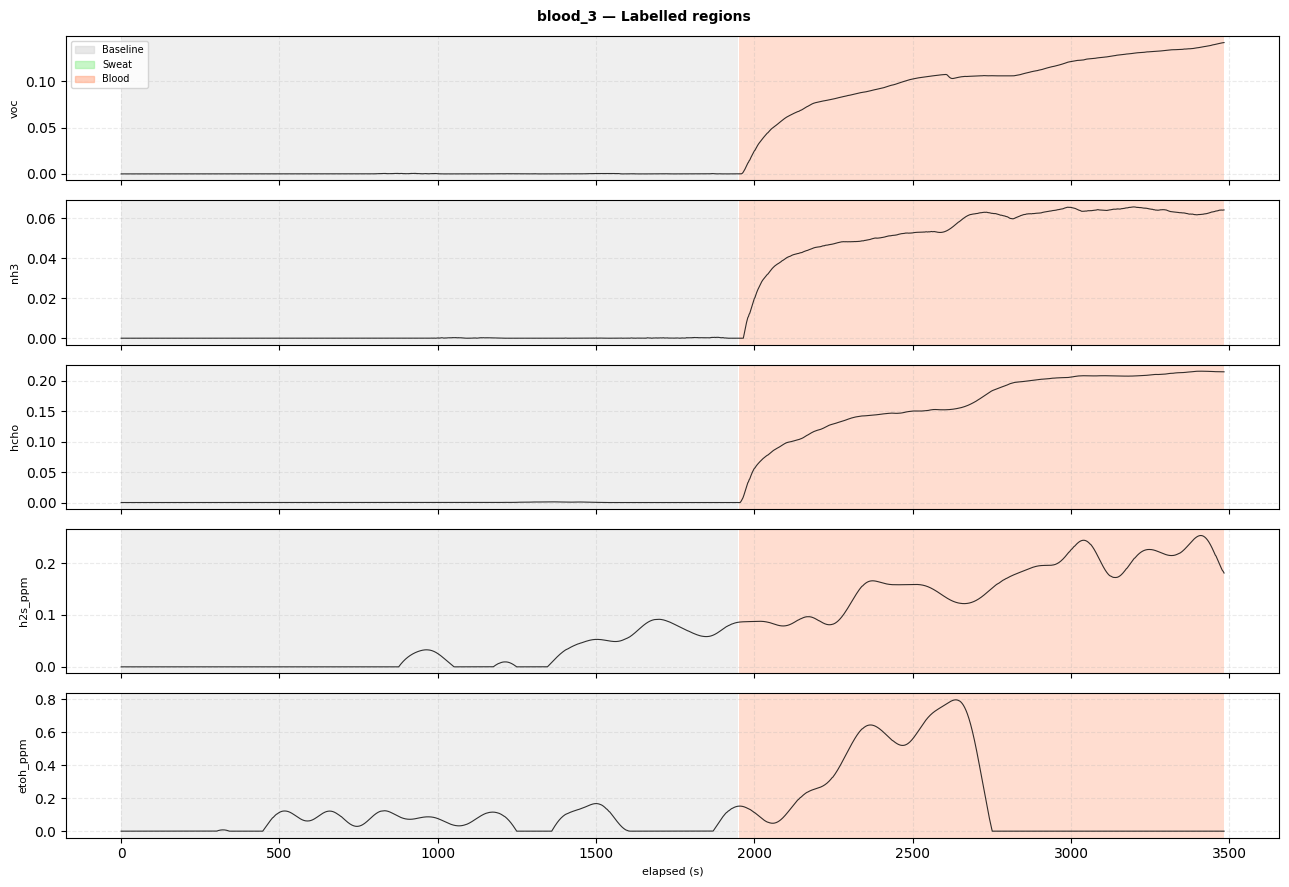

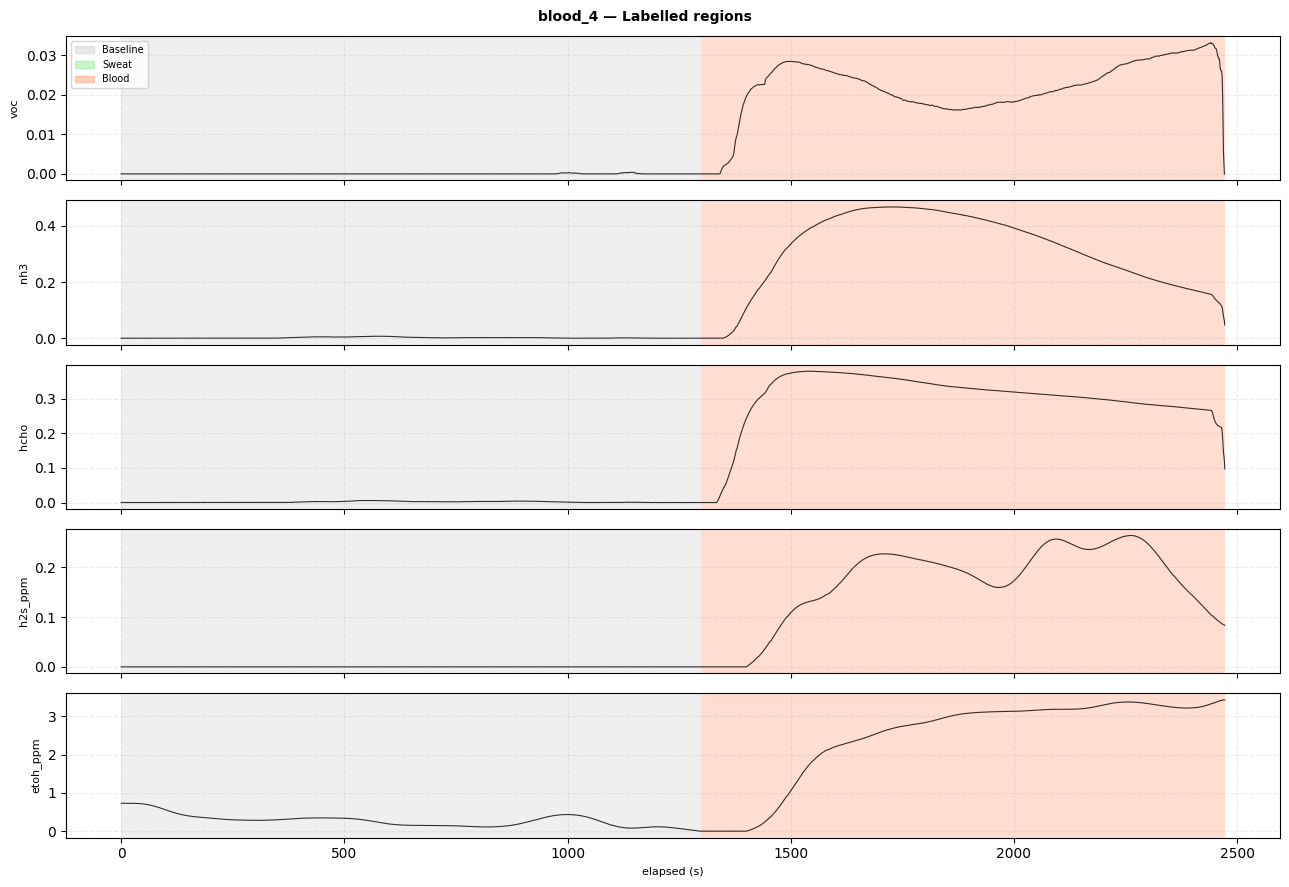

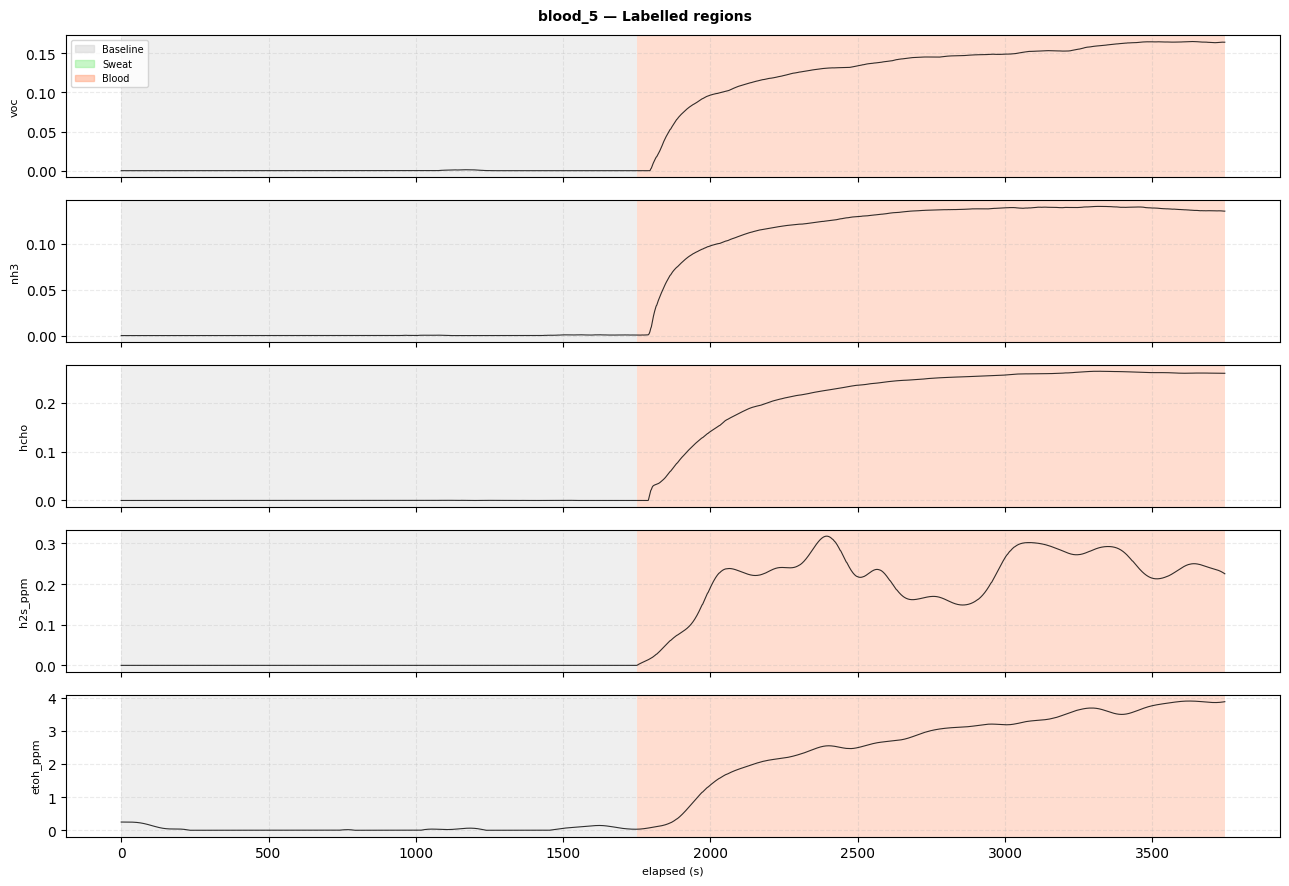

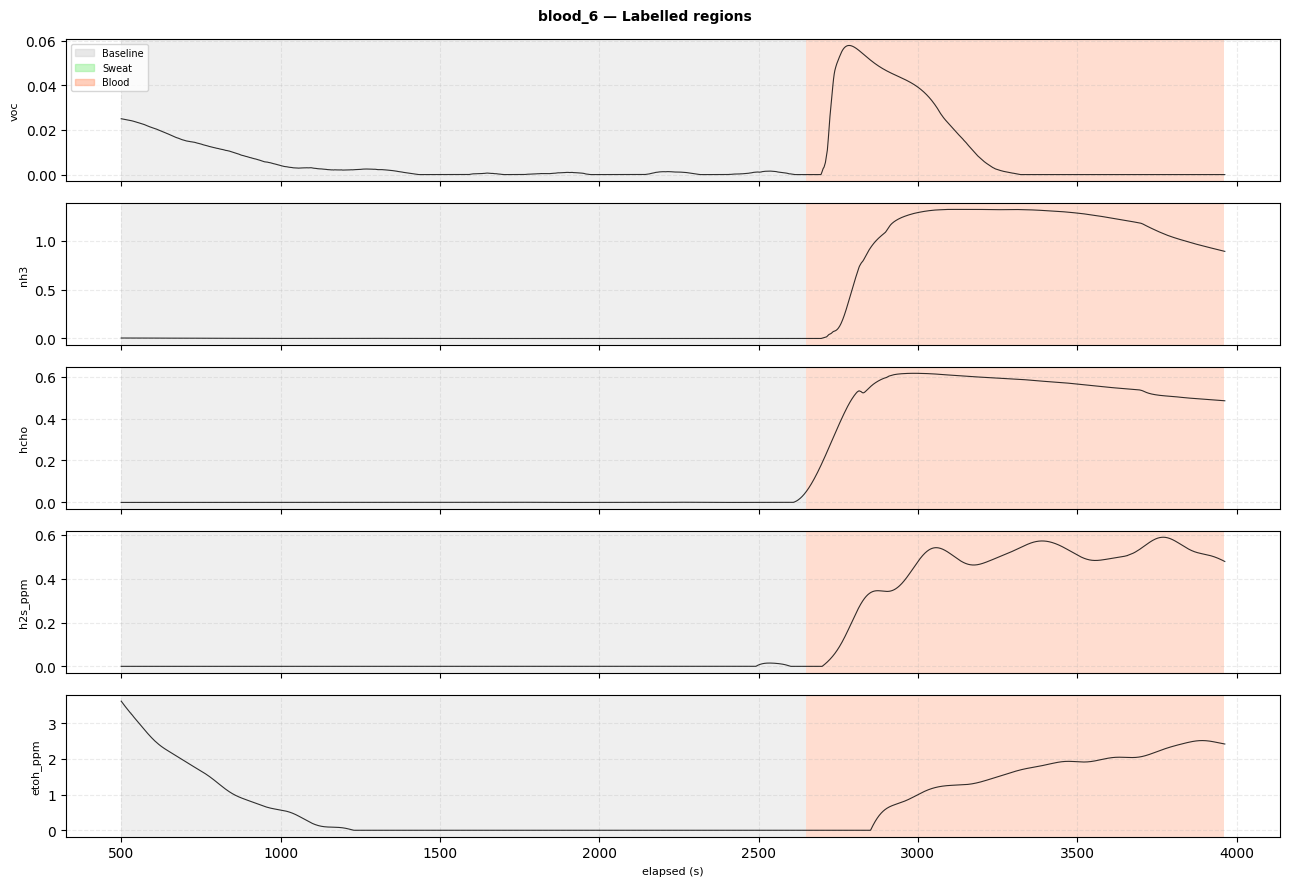

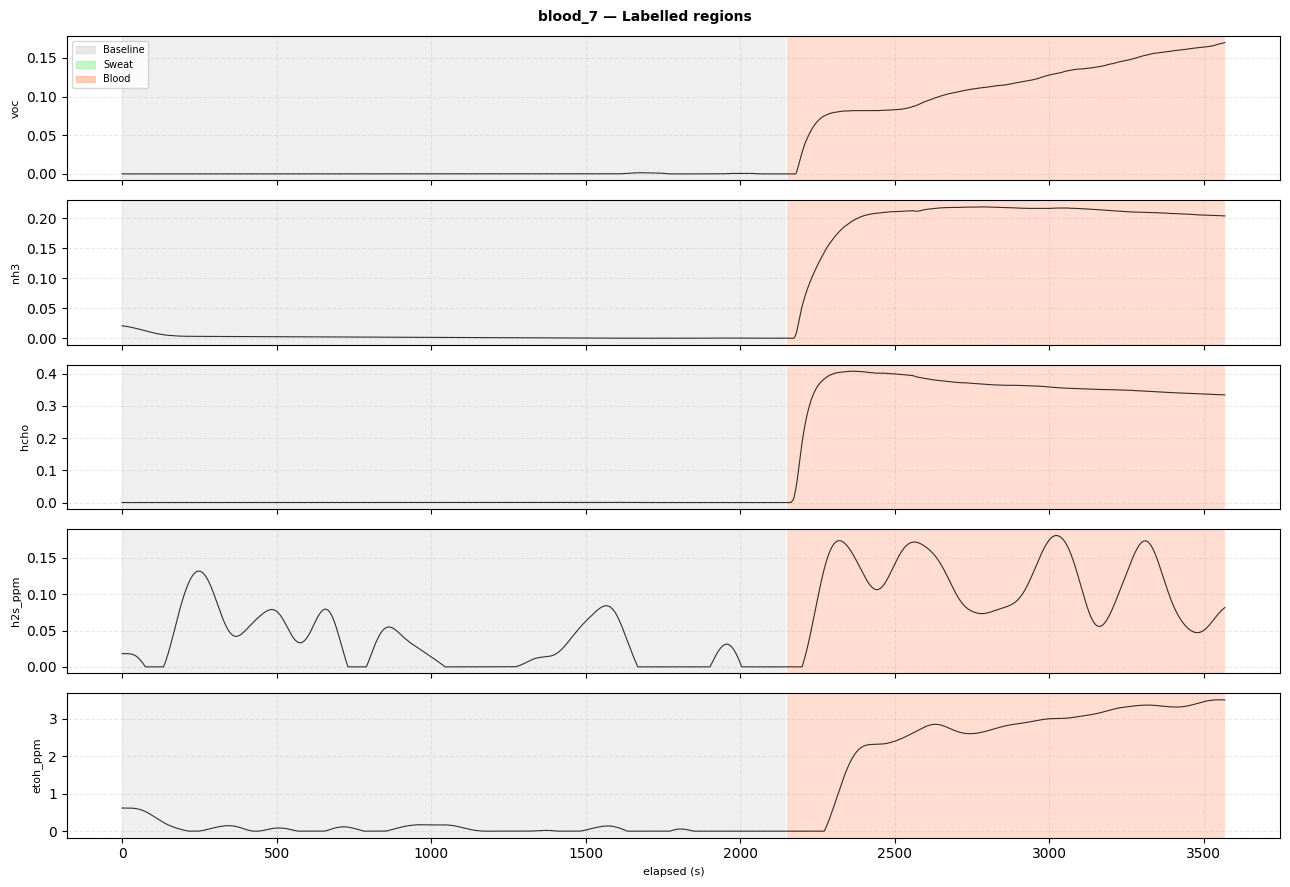

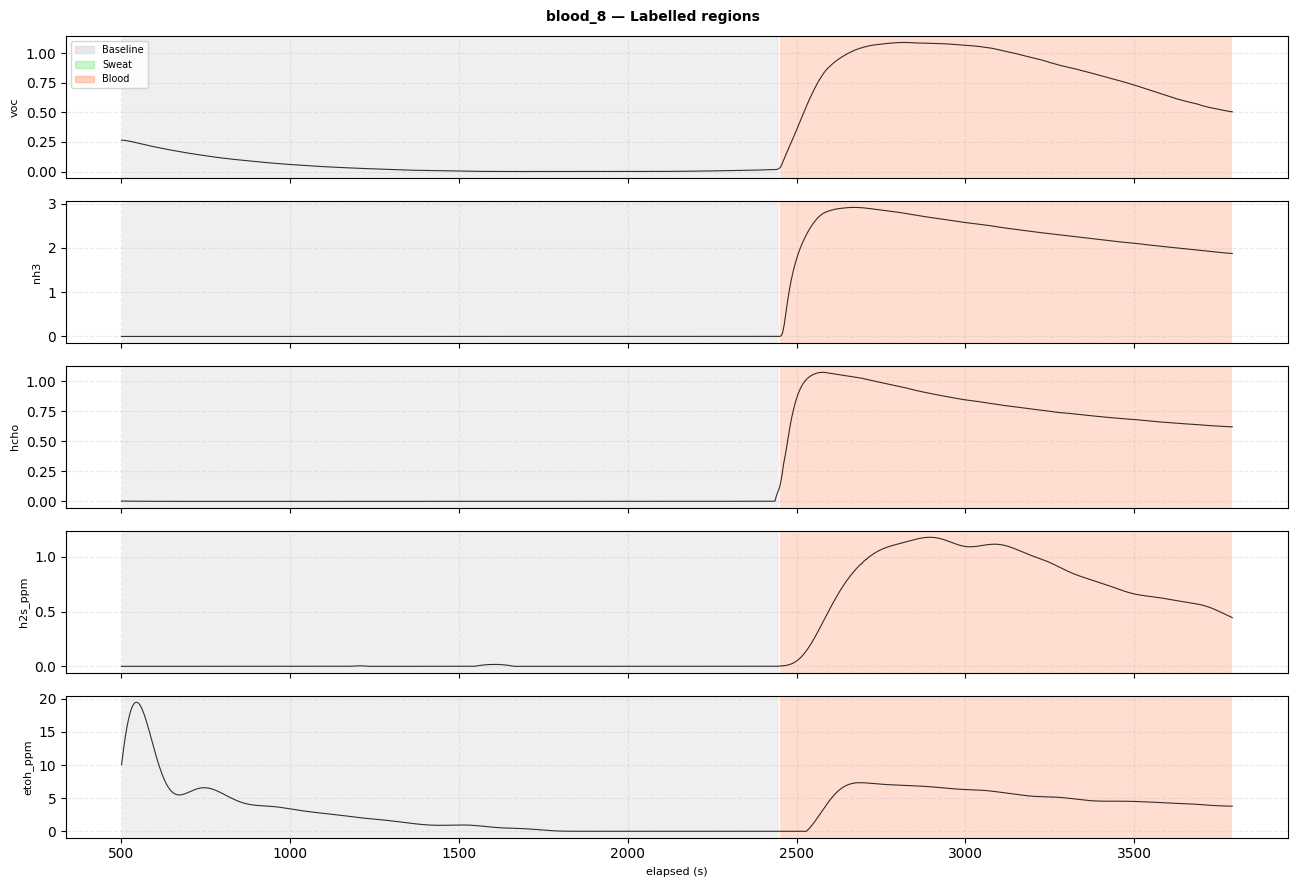

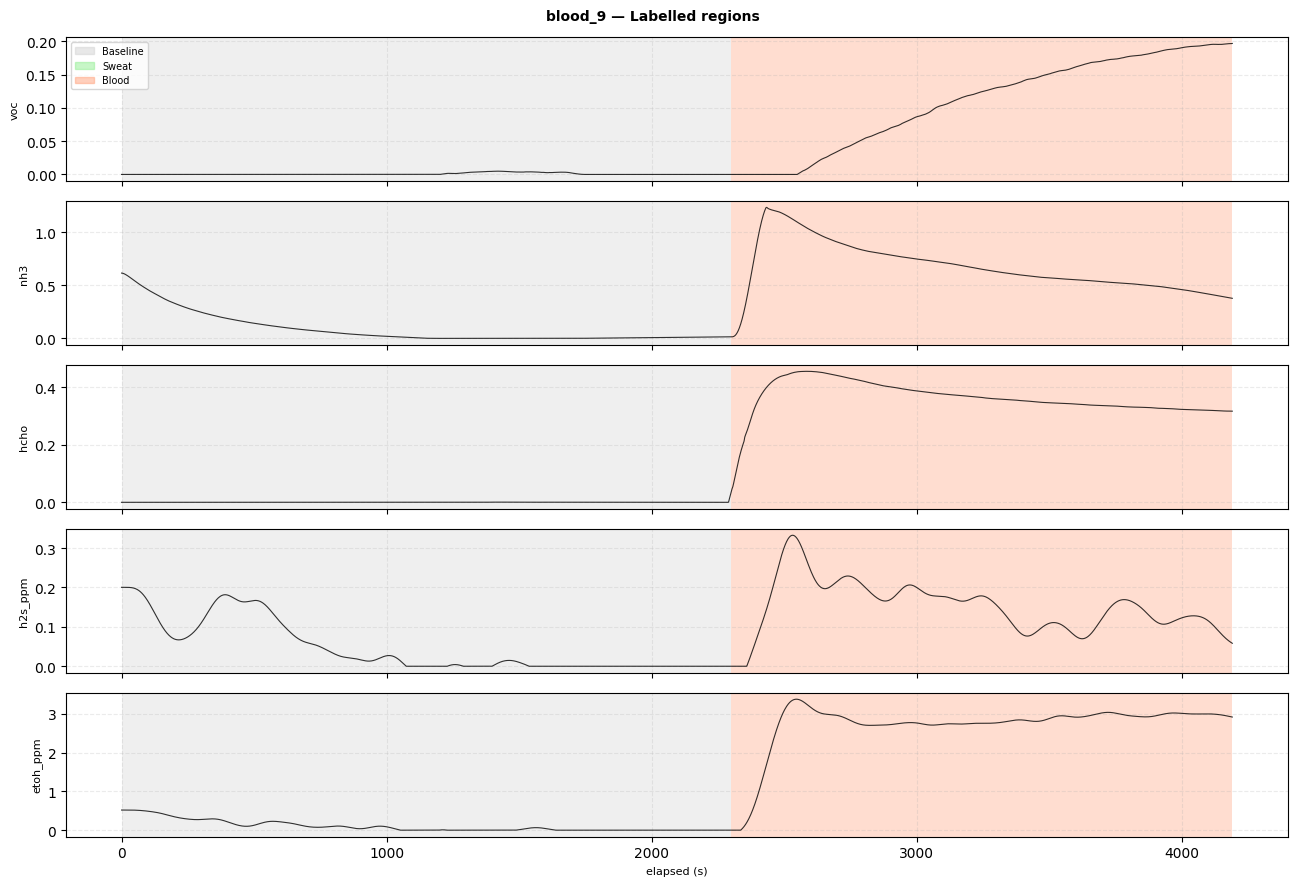

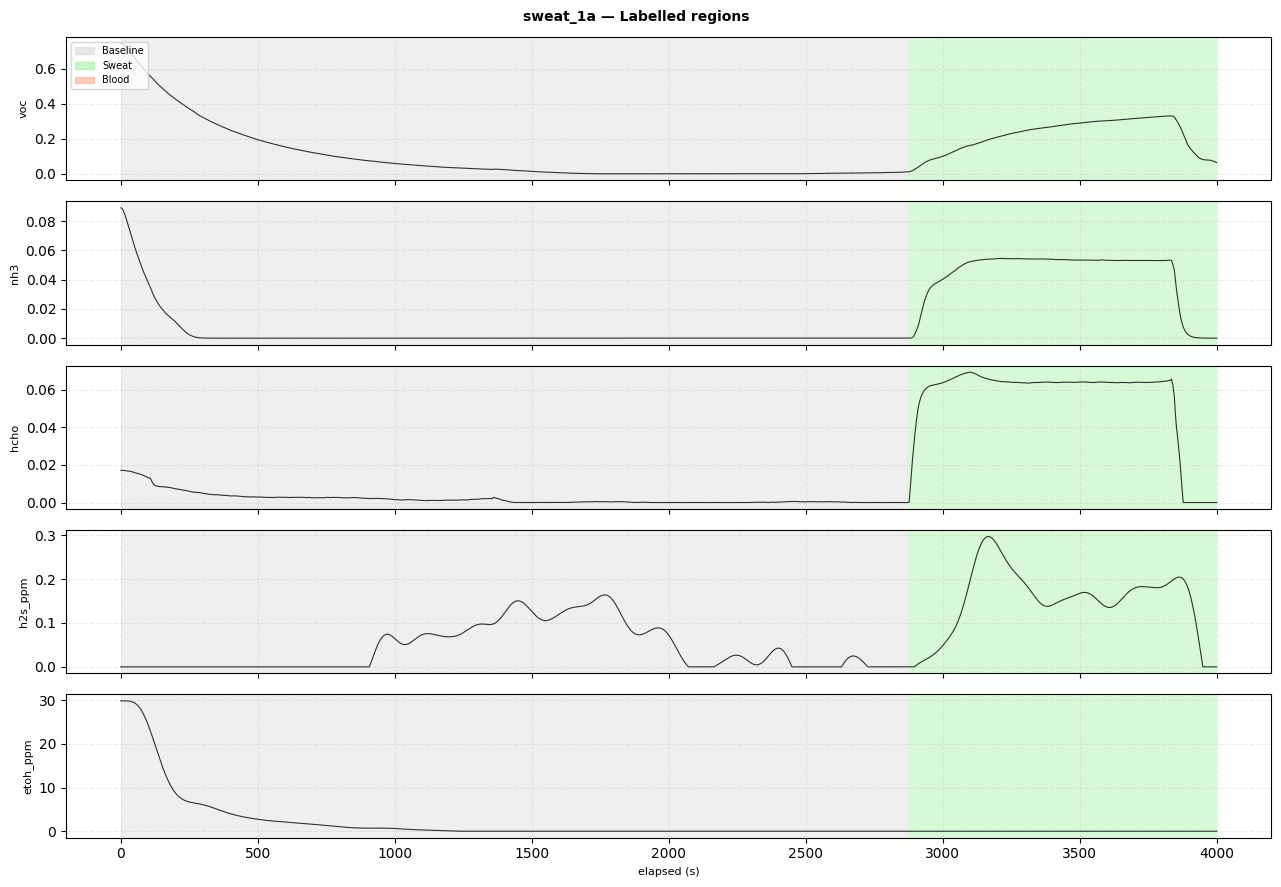

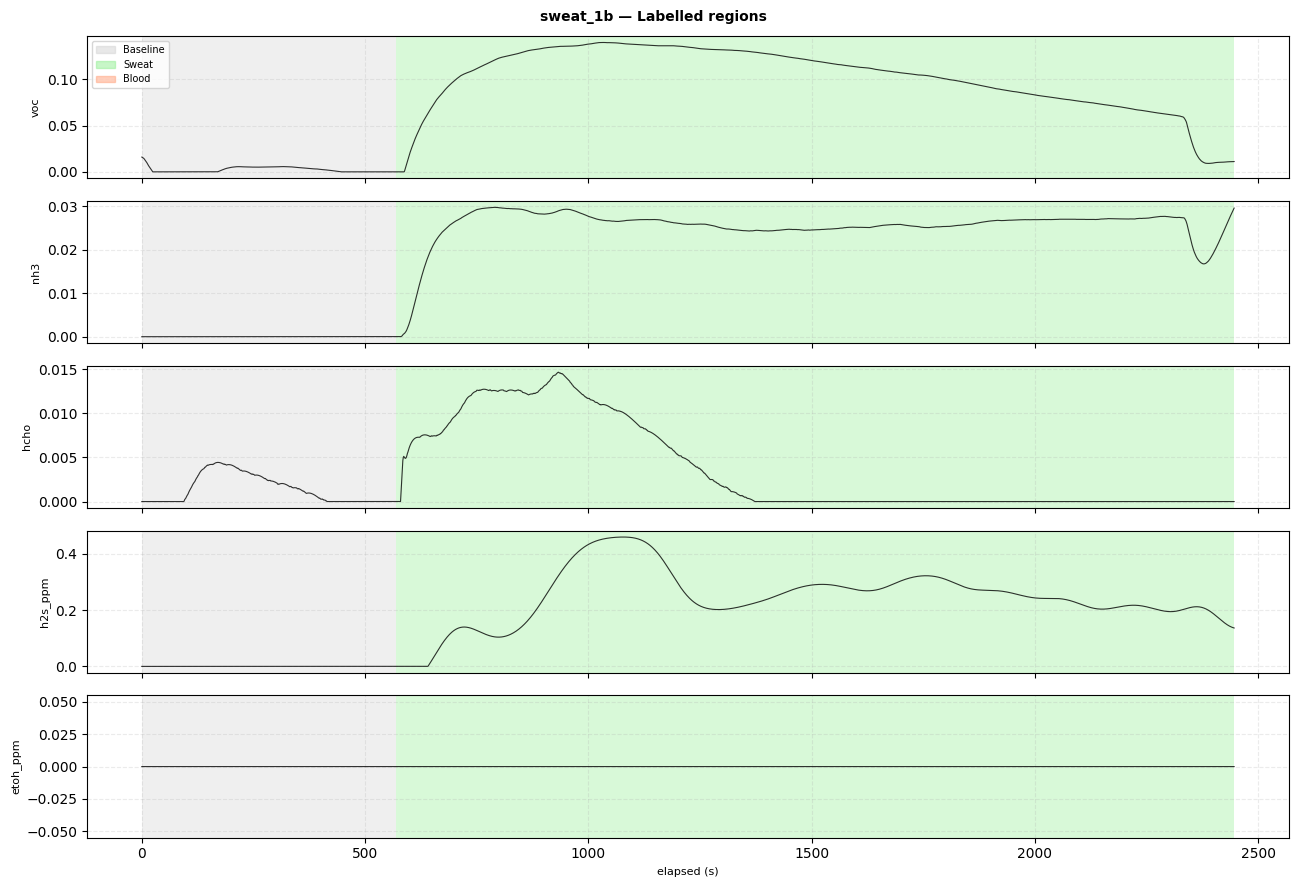

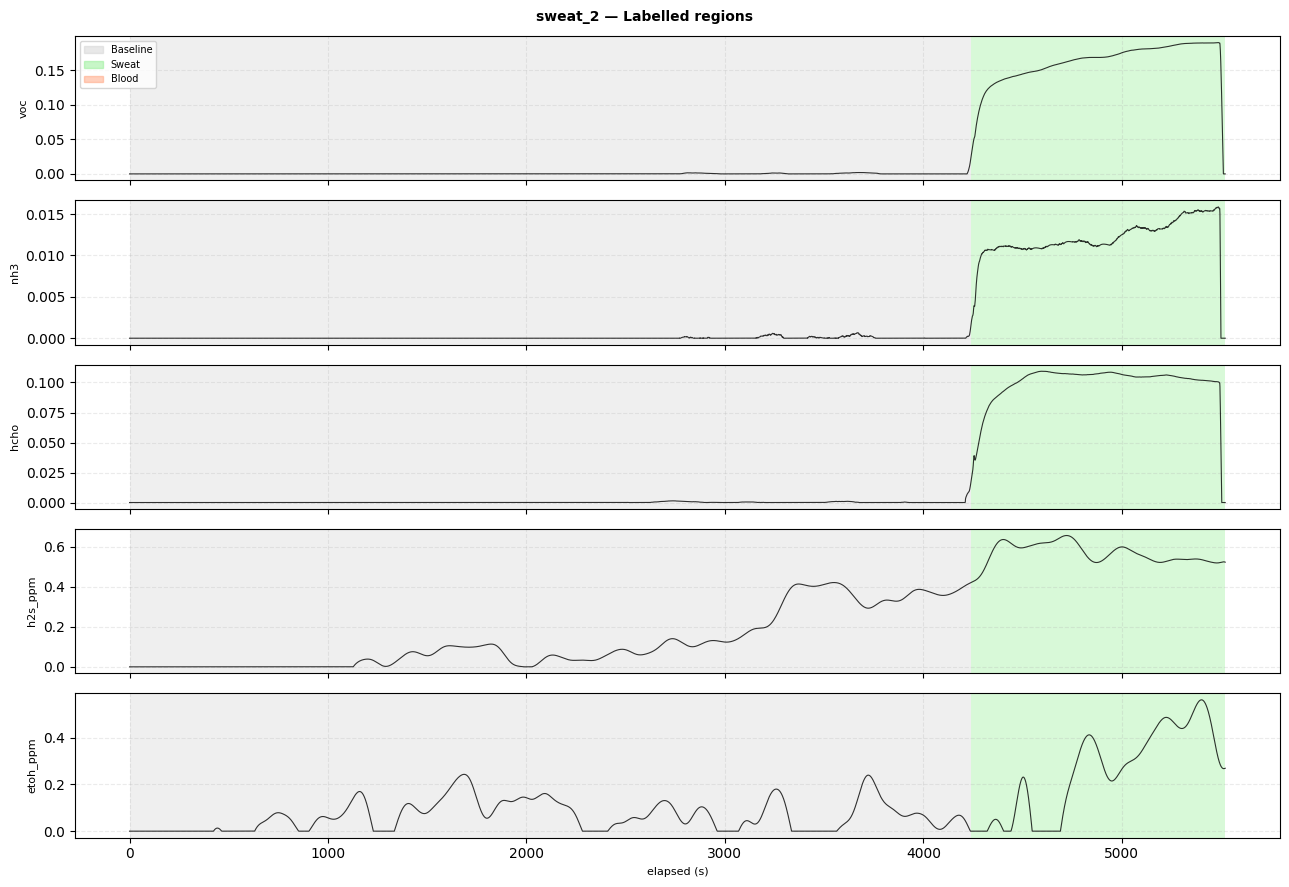

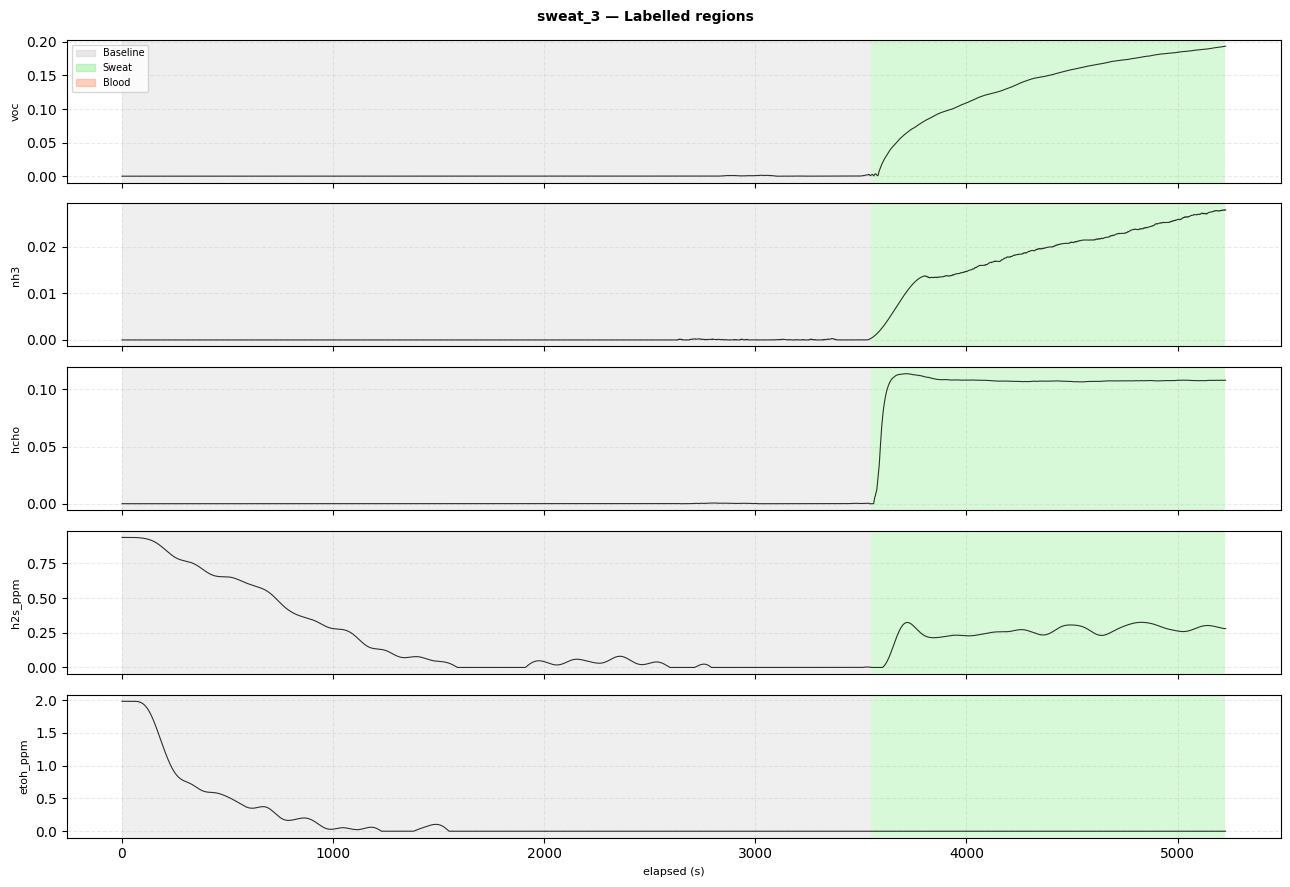

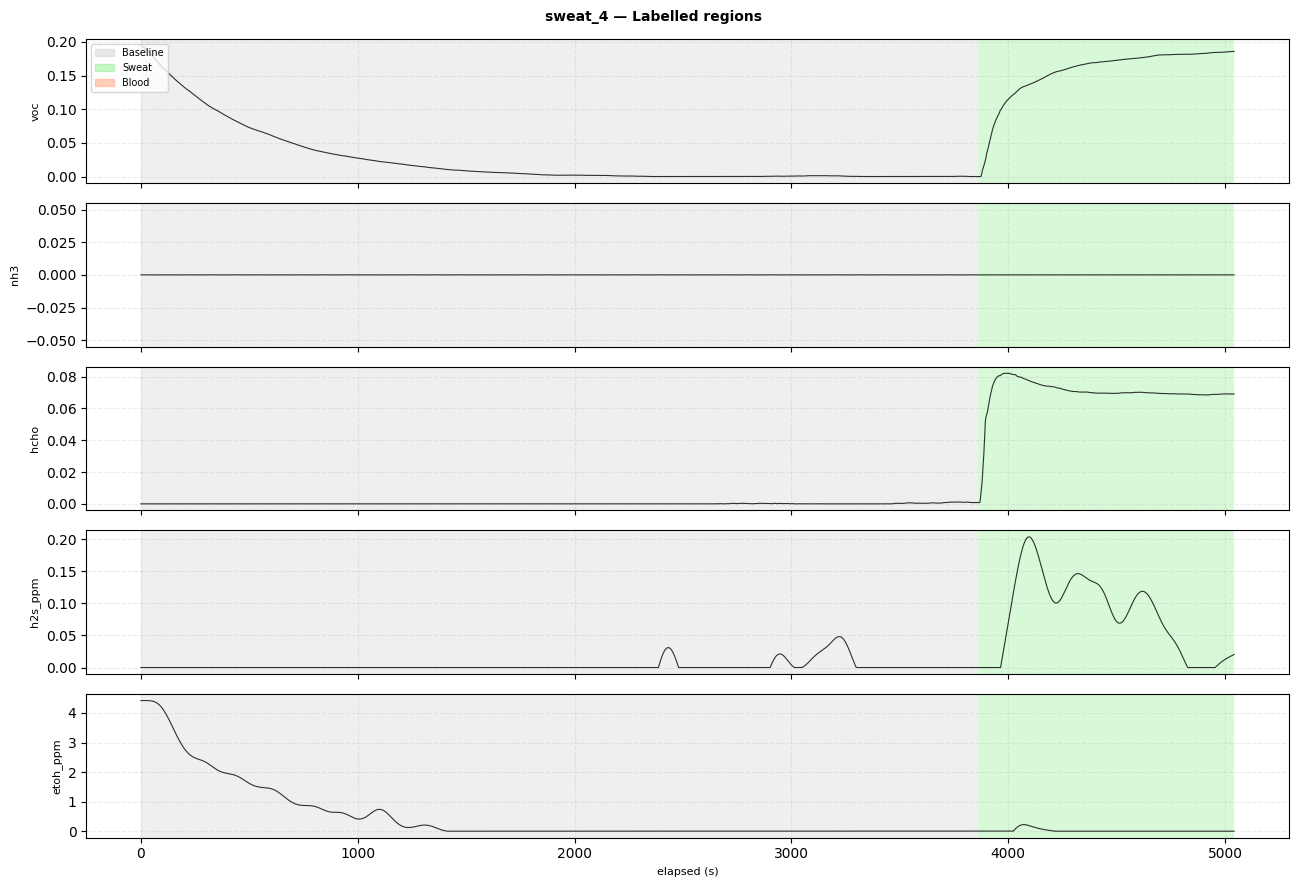

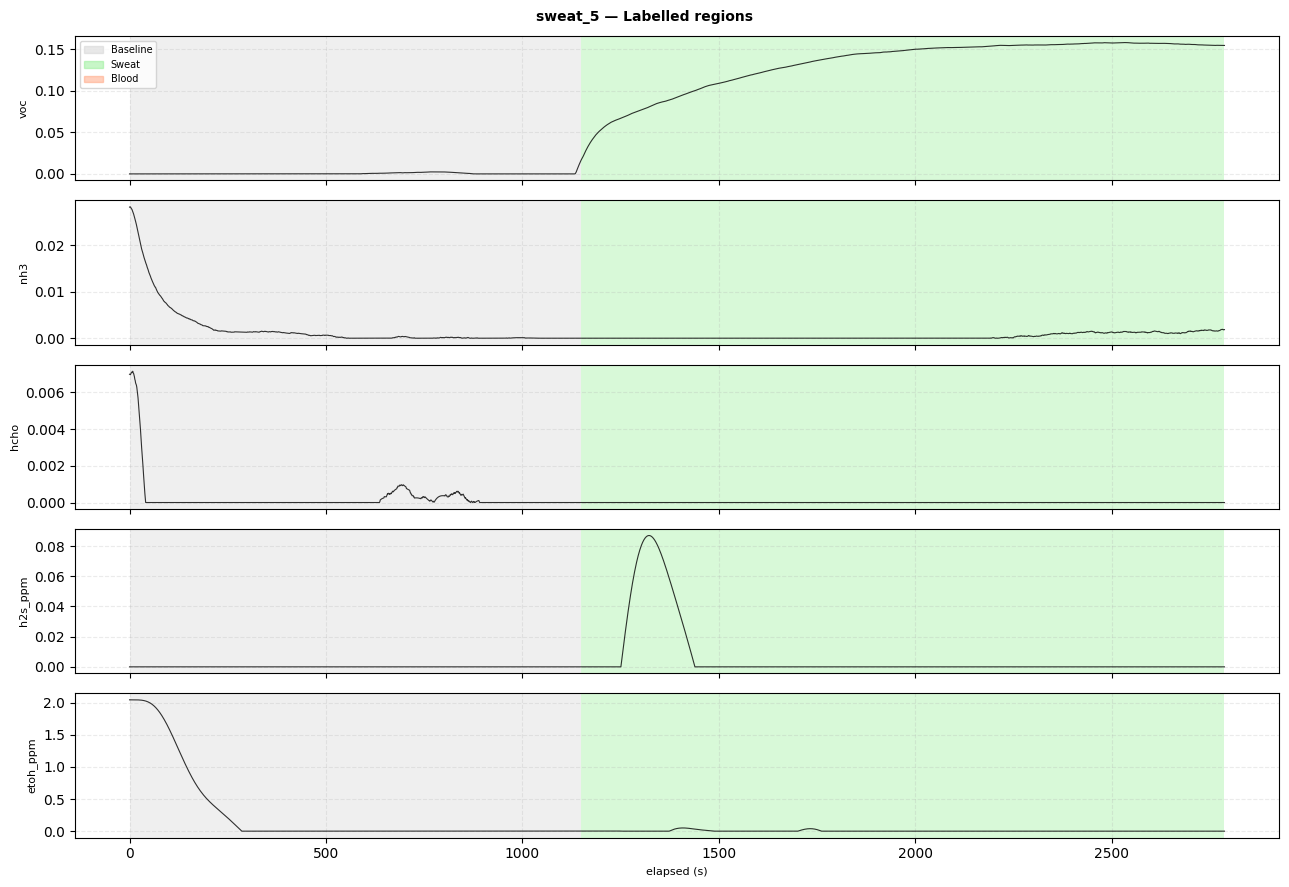

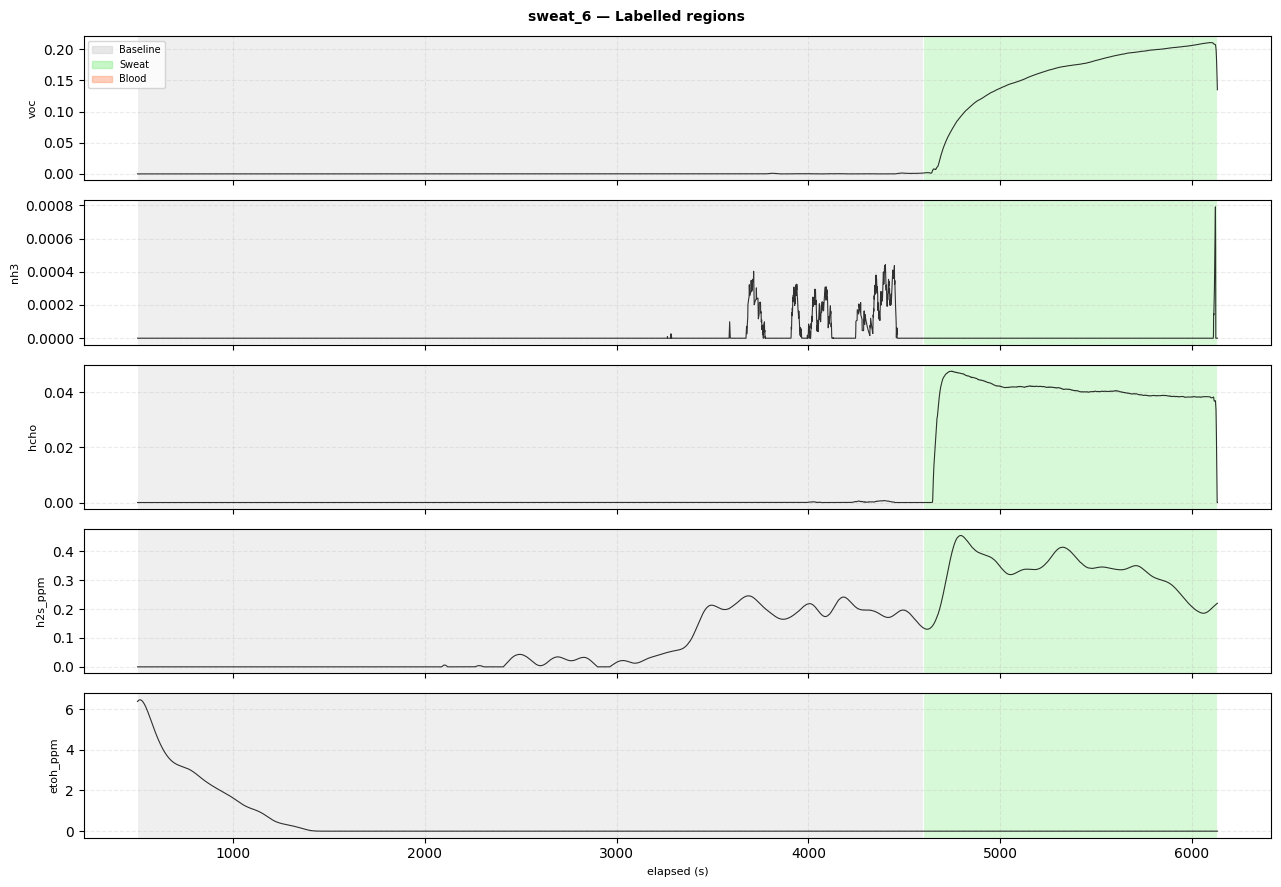

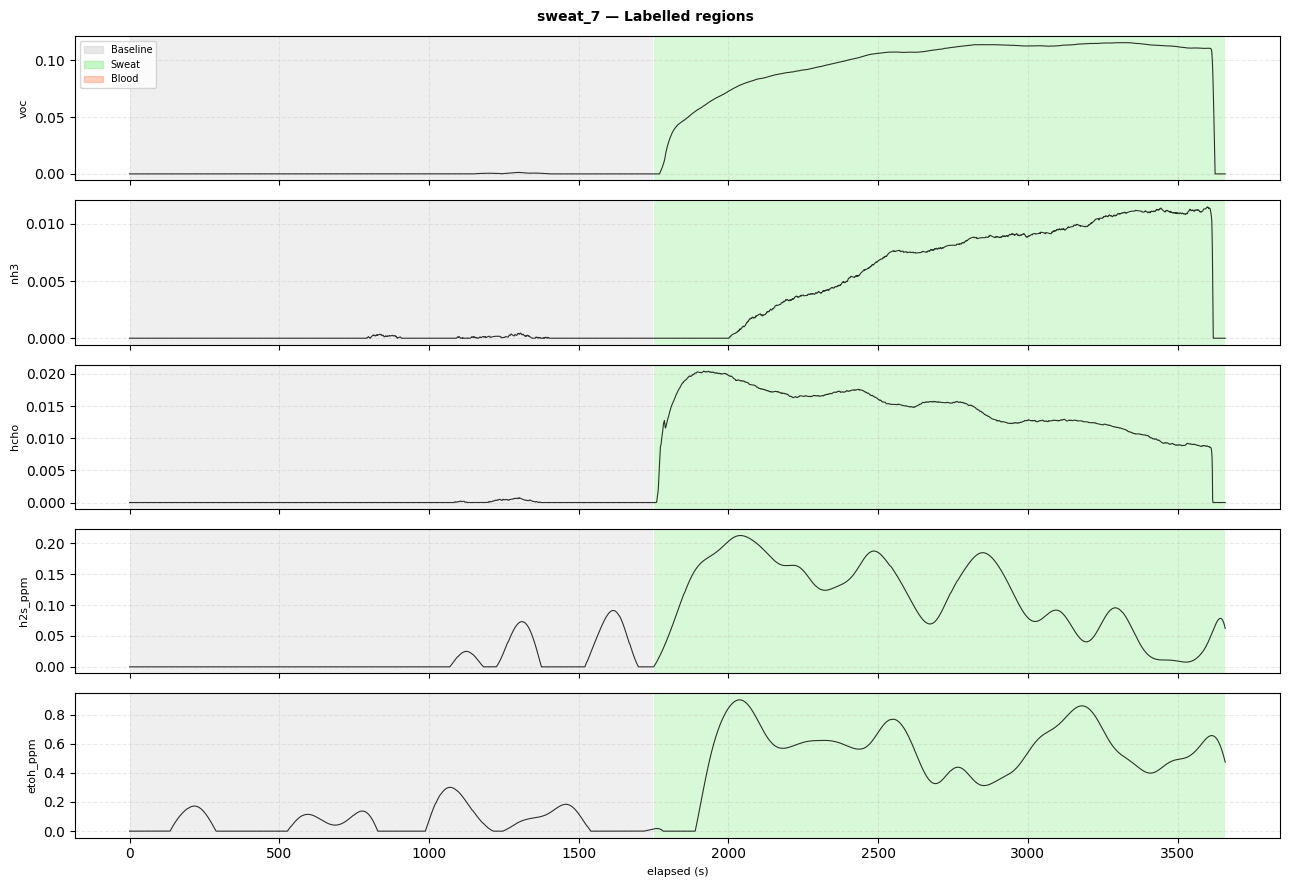

In [105]:
import matplotlib.patches as mpatches

REGION_COLORS = {
    LABEL_BASELINE: ("lightgrey",   "Baseline"),
    LABEL_SWEAT:    ("lightgreen",  "Sweat"),
    LABEL_BLOOD:    ("lightsalmon", "Blood"),
}

PLOT_COLS = ["voc", "nh3", "hcho", "h2s_ppm", "etoh_ppm"]

for key, df in sorted(datasets.items()):
    fig, axes = plt.subplots(len(PLOT_COLS), 1, figsize=(13, 9), sharex=True)
    fig.suptitle(f"{key} — Labelled regions", fontsize=10, fontweight="bold")

    # Build contiguous label blocks for shading
    label_blocks = df[["elapsed_s", "label"]].copy()
    label_blocks["block"] = (label_blocks["label"] != label_blocks["label"].shift()).cumsum()
    for _, grp in label_blocks.groupby("block"):
        t0  = grp["elapsed_s"].iloc[0]
        t1  = grp["elapsed_s"].iloc[-1]
        lbl = grp["label"].iloc[0]
        color, _ = REGION_COLORS[lbl]
        for ax in axes:
            ax.axvspan(t0, t1, color=color, alpha=0.35, linewidth=0)

    for ax, col in zip(axes, PLOT_COLS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.8, color="black", alpha=0.8)
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.25, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)

    patches = [mpatches.Patch(color=c, label=l, alpha=0.5)
               for _, (c, l) in REGION_COLORS.items()]
    axes[0].legend(handles=patches, fontsize=7, loc="upper left")

    plt.tight_layout()
    plt.show()

## Model Creation

### Helper Columns

Computed per row before windowing. Each column is causal (uses only past data) so compatible with real-time inference.

**Multi-scale rolling mean** — signal level over 15s, 30s, 60s lookbacks:
```
{col}_roll_mean_15,  {col}_roll_mean_30,  {col}_roll_mean_60
```

**Multi-scale rolling std** — signal volatility over 15s, 30s, 60s:
```
{col}_roll_std_15,  {col}_roll_std_30,  {col}_roll_std_60
```

**Rate of change (ROC)** — instantaneous change between consecutive samples:
```
{col}_roc
```

**Multi-scale rolling ROC** — smoothed rate of change over 15s, 30s, 60s:
```
{col}_roll_roc_15,  {col}_roll_roc_30,  {col}_roll_roc_60
```

**Acceleration** — rate of change of the ROC (2nd derivative). Captures whether the sensor response is speeding up or plateauing:
```
{col}_acc


In [88]:
CHANNELS = ["voc", "nh3", "hcho", "h2s_ppm", "etoh_ppm", "rh_pct"]
ROLL_WINDOWS = [15, 30, 60]   # seconds (= samples at 1 Hz)

for key in datasets:
    df = datasets[key].copy()

    for col in CHANNELS:
        # Rate of change (1st derivative)
        df[f"{col}_roc"] = df[col].diff()

        # Acceleration (2nd derivative)
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()

        # Multi-scale rolling mean, std, ROC
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()

    datasets[key] = df

# Summary
sample = datasets["sweat_1a"]
helper_cols = [c for c in sample.columns if any(
    c.endswith(s) for s in ["_roc", "_acc", "_mean_15", "_mean_30", "_mean_60",
                             "_std_15", "_std_30", "_std_60",
                             "_roc_15", "_roc_30", "_roc_60"]
)]
print(f"Helper columns added per dataset: {len(helper_cols)}")
print(f"Total columns: {len(sample.columns)}")
print(f"\nHelper columns:")
for c in helper_cols:
    print(f"  {c}")


Helper columns added per dataset: 66
Total columns: 75

Helper columns:
  voc_roc
  voc_acc
  voc_roll_mean_15
  voc_roll_std_15
  voc_roll_roc_15
  voc_roll_mean_30
  voc_roll_std_30
  voc_roll_roc_30
  voc_roll_mean_60
  voc_roll_std_60
  voc_roll_roc_60
  nh3_roc
  nh3_acc
  nh3_roll_mean_15
  nh3_roll_std_15
  nh3_roll_roc_15
  nh3_roll_mean_30
  nh3_roll_std_30
  nh3_roll_roc_30
  nh3_roll_mean_60
  nh3_roll_std_60
  nh3_roll_roc_60
  hcho_roc
  hcho_acc
  hcho_roll_mean_15
  hcho_roll_std_15
  hcho_roll_roc_15
  hcho_roll_mean_30
  hcho_roll_std_30
  hcho_roll_roc_30
  hcho_roll_mean_60
  hcho_roll_std_60
  hcho_roll_roc_60
  h2s_ppm_roc
  h2s_ppm_acc
  h2s_ppm_roll_mean_15
  h2s_ppm_roll_std_15
  h2s_ppm_roll_roc_15
  h2s_ppm_roll_mean_30
  h2s_ppm_roll_std_30
  h2s_ppm_roll_roc_30
  h2s_ppm_roll_mean_60
  h2s_ppm_roll_std_60
  h2s_ppm_roll_roc_60
  etoh_ppm_roc
  etoh_ppm_acc
  etoh_ppm_roll_mean_15
  etoh_ppm_roll_std_15
  etoh_ppm_roll_roc_15
  etoh_ppm_roll_mean_30
  etoh_pp

### Windowed Feature Extraction

Slide a **60s non-overlapping window** over labeled rows (sweat, blood, and undersampled baseline). Per window extract:

- **Mean, std, slope, max** for each channel and its helper columns (VOC, NH3, HCHO, H2S, EtOH)
- **Mean temp_C and rh_pct** as environmental context

Each window becomes one feature vector with a single class label (baseline=0, sweat=1, blood=2).

In [89]:
import numpy as np

WINDOW_SIZE = 60   # seconds = samples at 1 Hz

# Columns to extract features from (channels + all helper columns)
EXCLUDE_COLS = {"elapsed_s", "label", "temp_C", "rh_pct"}
FEATURE_COLS = [c for c in datasets["sweat_1a"].columns if c not in EXCLUDE_COLS]

def extract_window_features(window_df, feature_cols):
    features = {}
    t = np.arange(len(window_df))

    for col in feature_cols:
        vals = window_df[col].values
        features[f"{col}_mean"]  = np.nanmean(vals)
        features[f"{col}_std"]   = np.nanstd(vals)
        features[f"{col}_max"]   = np.nanmax(vals)
        slope, _ = np.polyfit(t, vals, 1) if len(vals) > 1 else (0.0, 0.0)
        features[f"{col}_slope"] = slope


    return features

# ── Slide window per (session, label) — never cross boundaries ────────────────
all_windows = []

for session, df in datasets.items():
    for label in [LABEL_BASELINE, LABEL_SWEAT, LABEL_BLOOD]:
        label_df = df[df["label"] == label].reset_index(drop=True)
        n_windows = len(label_df) // WINDOW_SIZE

        for i in range(n_windows):
            window = label_df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
            feats  = extract_window_features(window, FEATURE_COLS)
            feats["label"]   = label
            feats["session"] = session
            all_windows.append(feats)

windows_df = pd.DataFrame(all_windows)

# ── Undersample baseline to match largest sample class ───────────────────────
baseline_w = windows_df[windows_df["label"] == LABEL_BASELINE]
sweat_w    = windows_df[windows_df["label"] == LABEL_SWEAT]
blood_w    = windows_df[windows_df["label"] == LABEL_BLOOD]

n_target         = max(len(sweat_w), len(blood_w))
baseline_sampled = baseline_w.sample(n=min(n_target, len(baseline_w)), random_state=42)

windows_balanced = pd.concat([sweat_w, blood_w, baseline_sampled]).reset_index(drop=True)

print(f"Windows before balancing:")
print(f"  Baseline : {len(baseline_w)}")
print(f"  Sweat    : {len(sweat_w)}")
print(f"  Blood    : {len(blood_w)}")
print(f"\nAfter undersampling baseline → {len(baseline_sampled)} windows:")
print(f"  Total    : {len(windows_balanced)}")
print(f"  Features : {len(windows_balanced.columns) - 2}")  # exclude label + session

print(f"\nWindows per session:")
print(f"  {'Session':<12}  {'Baseline':>10}  {'Sweat':>8}  {'Blood':>8}  {'Total':>8}")
print(f"  {'-'*46}")
for session in windows_df['session'].unique():
    s = windows_df[windows_df['session'] == session]
    b  = (s['label'] == LABEL_BASELINE).sum()
    sw = (s['label'] == LABEL_SWEAT).sum()
    bl = (s['label'] == LABEL_BLOOD).sum()
    print(f"  {session:<12}  {b:>10}  {sw:>8}  {bl:>8}  {len(s):>8}")
print(f"  {'-'*46}")
totals = windows_df.groupby('label').size()
print(f"  {'TOTAL':<12}  {totals.get(LABEL_BASELINE,0):>10}  {totals.get(LABEL_SWEAT,0):>8}  {totals.get(LABEL_BLOOD,0):>8}  {len(windows_df):>8}")


Windows before balancing:
  Baseline : 102
  Sweat    : 43
  Blood    : 49

After undersampling baseline → 49 windows:
  Total    : 141
  Features : 284

Windows per session:
  Session         Baseline     Sweat     Blood     Total
  ----------------------------------------------
  sweat_1a              49        15         0        64
  sweat_1b              11        28         0        39
  blood_0               31         0        29        60
  blood_1               11         0        20        31
  ----------------------------------------------
  TOTAL                102        43        49       194


### Training and Evaluation — Random Forest with LOSO (Run 1)

**Setup:**
- 141 total windows (60s non-overlapping) across 4 sessions
- 3-class classification: baseline=0, sweat=1, blood=2
- Baseline undersampled globally to match largest sample class
- Features: mean, std, slope, max for all 5 channels + all helper columns (ROC, acceleration, rolling mean/std/ROC at 15s/30s/60s) + rh_pct helpers
- Model: Random Forest, 200 trees, class_weight="balanced"
- Evaluation: GroupKFold (n_splits=4), split by session

**Observations:**
- Training accuracy is perfect every fold — model overfits to training data
- Fold 3 (blood_0 held out) collapses to random chance (0.333) — blood_0 and blood_1 are too different for one to predict the other
- Fold 4 (blood_1 held out) is perfect — blood_1 is well represented by training
- High std (0.253) makes the mean unreliable
- Too many features relative to window count — helper columns likely adding noise

**Next steps:** Feature selection — restrict to NH3 and HCHO channels which visually show the strongest discrimination between classes.

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

X      = windows_balanced.drop(columns=["label", "session"])
y      = windows_balanced["label"]
groups = windows_balanced["session"]

gkf   = GroupKFold(n_splits=4)
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

results = cross_validate(
    model, X, y,
    cv=gkf.split(X, y, groups),
    scoring=["accuracy"],
    return_train_score=True,
)

print("LOSO Cross-Validation Results")
print("=" * 40)
print(f"  {'Fold':<8}  {'Train Acc':>10}  {'Val Acc':>10}")
print(f"  {'-'*40}")
for i in range(4):
    print(f"  {i+1:<8}  "
          f"{results['train_accuracy'][i]:>10.3f}  "
          f"{results['test_accuracy'][i]:>10.3f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<8}  "
      f"{results['train_accuracy'].mean():>10.3f}  "
      f"{results['test_accuracy'].mean():>10.3f}")
print(f"  {'Std':<8}  "
      f"{results['train_accuracy'].std():>10.3f}  "
      f"{results['test_accuracy'].std():>10.3f}")

# ── Train final model on all data ─────────────────────────────────────────────
final_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X, y)
print(f"\nFinal model trained on all {len(X)} windows.")


LOSO Cross-Validation Results
  Fold       Train Acc     Val Acc
  ----------------------------------------
  1              1.000       0.791
  2              1.000       0.884
  3              1.000       0.333
  4              1.000       1.000
  ----------------------------------------
  Mean           1.000       0.752
  Std            0.000       0.253

Final model trained on all 141 windows.


### Training and Evaluation — Random Forest (Run 2)

**Changes from Run 1:**

1. **Reduce trees: 200 → 100**
2. **Feature reduction** — remove roll_mean, roll_std, acc; keep raw aggregates + ROC columns
3. **Simple 80/20 split** — train on 80% of all windows, validate on the remaining 20% (stratified by label so each class is proportionally represented in both sets)

This uses everything we have. Future sessions will serve as true out-of-sample validation.


In [91]:
# ── Feature reduction: drop roll_mean, roll_std, acc ──────────────────────────
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

REMOVE_PATTERNS = ["_roll_mean_", "_roll_std_", "_acc"]

all_feature_cols = [c for c in windows_balanced.columns if c not in ("label", "session")]
feature_cols_r2 = [c for c in all_feature_cols
                   if not any(p in c for p in REMOVE_PATTERNS)]

print(f"Run 1 features: {len(all_feature_cols)}")
print(f"Run 2 features: {len(feature_cols_r2)}\n")

X2     = windows_balanced[feature_cols_r2]
y2     = windows_balanced["label"]
groups = windows_balanced["session"]

# ── 80/20 split — stratified by label ─────────────────────────────────────────
X_train, X_test, y_train, y_test, grp_train, grp_test = train_test_split(
    X2, y2, groups,
    test_size=0.2,
    random_state=42,
    stratify=y2,
)

print(f"Train: {len(X_train)} windows")
for sess, count in grp_train.value_counts().sort_index().items():
    print(f"  {sess}: {count} windows")

print(f"\nTest:  {len(X_test)} windows")
for sess, count in grp_test.value_counts().sort_index().items():
    print(f"  {sess}: {count} windows")

# ── Train ──────────────────────────────────────────────────────────────────────
model_r2 = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model_r2.fit(X_train, y_train)

# ── Validate ───────────────────────────────────────────────────────────────────
y_pred = model_r2.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

CLASS_NAMES = ["baseline", "sweat", "blood"]
print(f"\nOverall accuracy: {acc:.3f}\n")
print(f"  {'Class':<12}  {'Precision':>10}  {'Recall':>8}  {'Support':>8}")
print(f"  {'-'*44}")
for i, name in enumerate(CLASS_NAMES):
    prec = precision_score(y_test, y_pred, labels=[i], average='micro', zero_division=0)
    rec  = recall_score(y_test, y_pred, labels=[i], average='micro', zero_division=0)
    sup  = int((y_test == i).sum())
    print(f"  {name:<12}  {prec:>10.3f}  {rec:>8.3f}  {sup:>8}")

# ── Per-session breakdown ──────────────────────────────────────────────────────
print("\nPer-session accuracy:")
for sess in sorted(grp_test.unique()):
    mask  = (grp_test == sess).values
    acc_s = accuracy_score(y_test.iloc[mask], y_pred[mask])
    n     = mask.sum()
    print(f"  {sess:<12}: {acc_s:.3f}  ({n} windows)")


Run 1 features: 284
Run 2 features: 116

Train: 112 windows
  blood_0: 33 windows
  blood_1: 22 windows
  sweat_1a: 31 windows
  sweat_1b: 26 windows

Test:  29 windows
  blood_0: 10 windows
  blood_1: 3 windows
  sweat_1a: 12 windows
  sweat_1b: 4 windows

Overall accuracy: 0.966

  Class          Precision    Recall   Support
  --------------------------------------------
  baseline           1.000     1.000        10
  sweat              0.900     1.000         9
  blood              1.000     0.900        10

Per-session accuracy:
  blood_0     : 0.900  (10 windows)
  blood_1     : 1.000  (3 windows)
  sweat_1a    : 1.000  (12 windows)
  sweat_1b    : 1.000  (4 windows)


### Feature Importances

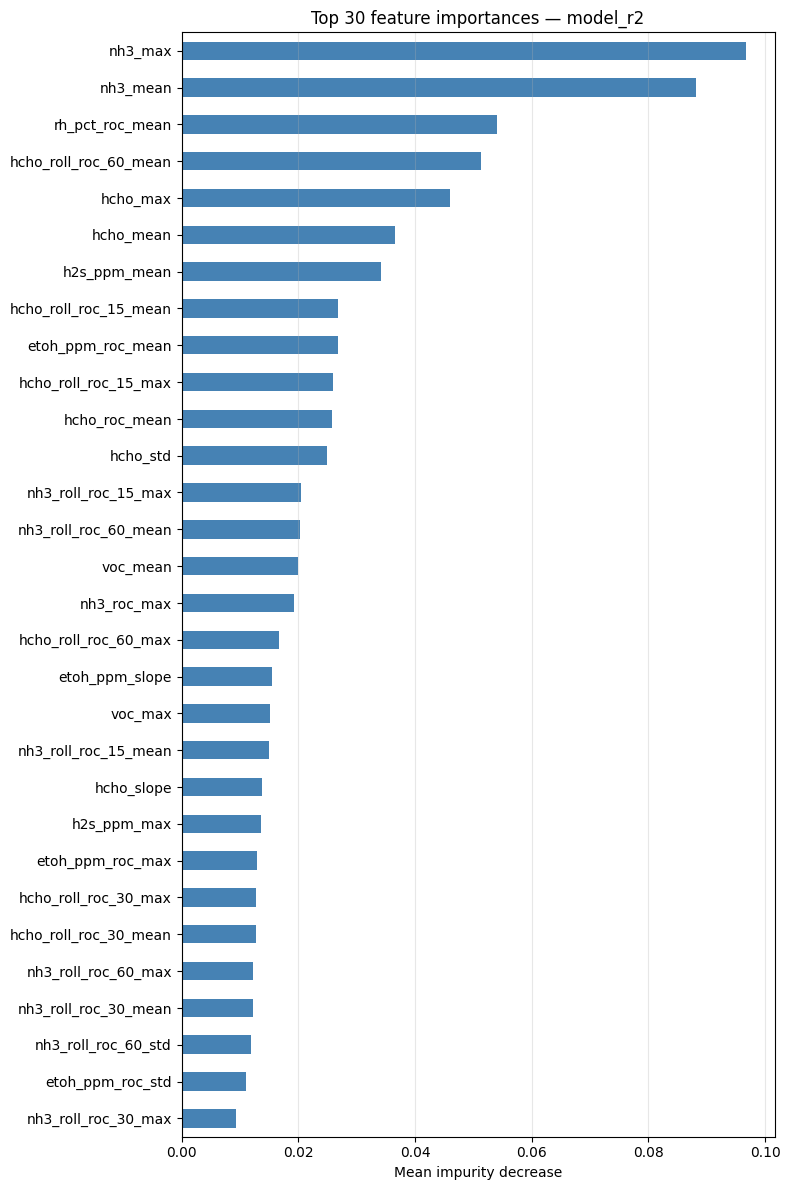

Top 10:
  nh3_max                                   0.0968
  nh3_mean                                  0.0882
  rh_pct_roc_mean                           0.0540
  hcho_roll_roc_60_mean                     0.0514
  hcho_max                                  0.0460
  hcho_mean                                 0.0365
  h2s_ppm_mean                              0.0341
  hcho_roll_roc_15_mean                     0.0268
  etoh_ppm_roc_mean                         0.0267
  hcho_roll_roc_15_max                      0.0258


In [92]:
importances = pd.Series(model_r2.feature_importances_, index=feature_cols_r2).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 12))
importances.tail(30).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean impurity decrease")
ax.set_title("Top 30 feature importances — model_r2")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10:")
for feat, imp in importances.iloc[::-1].head(10).items():
    print(f"  {feat:<40}  {imp:.4f}")


### Save Model

In [93]:
import joblib, json, os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Model
joblib.dump(model_r2, f"{MODEL_DIR}/rf_model_r2.joblib")

# Feature column list — needed at inference time to select the right columns
with open(f"{MODEL_DIR}/feature_cols_r2.json", "w") as f:
    json.dump(feature_cols_r2, f, indent=2)

# Training windows — for reproducibility and future retraining
windows_balanced.to_parquet(f"{MODEL_DIR}/windows_balanced.parquet", index=False)

print(f"Saved to {MODEL_DIR}/")
print(f"  rf_model_r2.joblib       — trained RandomForest ({len(feature_cols_r2)} features, {len(windows_balanced)} windows)")
print(f"  feature_cols_r2.json     — {len(feature_cols_r2)} feature names")
print(f"  windows_balanced.parquet — {len(windows_balanced)} training windows  ({windows_balanced['label'].value_counts().to_dict()})")


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

## Test — Apply Model to sweat_1a

Load the raw sweat_1a session, run the same feature pipeline, and classify each 60s window. Colour bands on the plot show what the model predicts for each window.

Loaded sweat_1a: 3909 rows, 4000s

  Window   t_start     t_end    Prediction
  ────────────────────────────────────────────
       1         0s        60s      baseline
       2        61s       122s      baseline
       3       123s       183s      baseline
       4       184s       245s      baseline
       5       246s       306s      baseline
       6       307s       368s      baseline
       7       369s       429s      baseline
       8       430s       490s      baseline
       9       491s       552s      baseline
      10       553s       613s      baseline
      11       614s       675s      baseline
      12       676s       736s      baseline
      13       737s       797s      baseline
      14       798s       859s      baseline
      15       860s       920s      baseline
      16       921s       982s      baseline
      17       983s      1043s      baseline
      18      1044s      1104s      baseline
      19      1105s      1166s      baseline
      20      1167s 

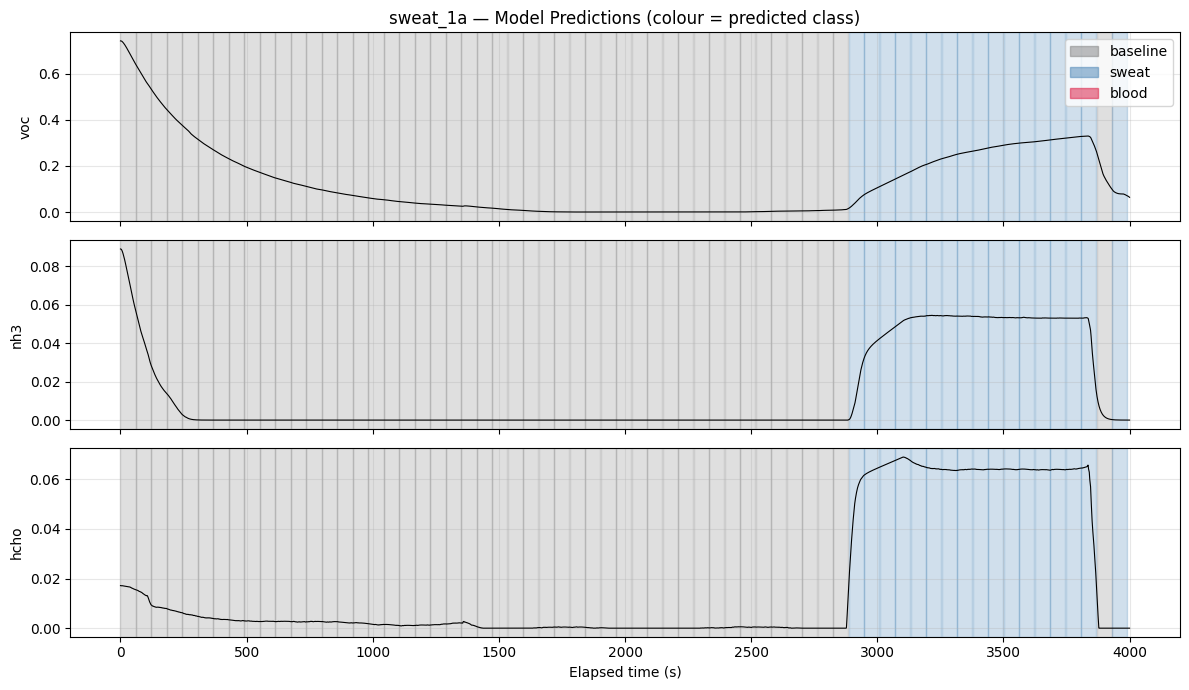

In [ ]:
# ── Helper: load a session, extract windows, classify, plot ───────────────────
def classify_session(pkl_name, title):
    mems = pd.read_pickle(os.path.join(PROCESSED, f"mems_{pkl_name}.pkl"))
    spec = pd.read_pickle(os.path.join(PROCESSED, f"spec_{pkl_name}.pkl"))
    df   = pd.merge(mems, spec, on="elapsed_s", how="inner")
    print(f"Loaded {pkl_name}: {len(df)} rows, {df['elapsed_s'].max():.0f}s")

    # Helper columns
    for col in CHANNELS:
        df[f"{col}_roc"] = df[col].diff()
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()

    # Window extraction
    test_windows = []
    for i in range(len(df) // WINDOW_SIZE):
        window = df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
        feats  = extract_window_features(window, FEATURE_COLS)
        feats["t_start"] = window["elapsed_s"].iloc[0]
        feats["t_end"]   = window["elapsed_s"].iloc[-1]
        test_windows.append(feats)

    test_df_w = pd.DataFrame(test_windows)
    preds     = model_r2.predict(test_df_w[feature_cols_r2])

    CLASS_NAMES = {0: "baseline", 1: "sweat", 2: "blood"}
    COLORS      = {0: "grey", 1: "steelblue", 2: "crimson"}

    # Print
    print(f"\n{'Window':>8}  {'t_start':>8}  {'t_end':>8}  {'Prediction':>12}")
    print(f"  {'─'*44}")
    for i, (pred, row) in enumerate(zip(preds, test_df_w.itertuples())):
        print(f"  {i+1:>6}  {row.t_start:>8.0f}s  {row.t_end:>8.0f}s  {CLASS_NAMES[pred]:>12}")

    counts = pd.Series(preds).map(CLASS_NAMES).value_counts()
    print(f"\nSummary: {dict(counts)}")

    # Plot
    import matplotlib.patches as mpatches
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for ax, col in zip(axes, ["voc", "nh3", "hcho"]):
        ax.plot(df["elapsed_s"], df[col], color="black", linewidth=0.8)
        for pred, row in zip(preds, test_df_w.itertuples()):
            ax.axvspan(row.t_start, row.t_end, alpha=0.25, color=COLORS[pred])
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    legend_patches = [mpatches.Patch(color=COLORS[k], alpha=0.5, label=CLASS_NAMES[k])
                      for k in sorted(COLORS)]
    axes[0].legend(handles=legend_patches, loc="upper right")
    axes[0].set_title(f"{title} — Model Predictions (colour = predicted class)")
    axes[-1].set_xlabel("Elapsed time (s)")
    plt.tight_layout()
    plt.show()

import os
classify_session("sweat_1a", "sweat_1a")


### Test — sweat_1b

Loaded sweat_1b: 2390 rows, 2446s

  Window   t_start     t_end    Prediction
  ────────────────────────────────────────────
       1         0s        60s      baseline
       2        61s       122s      baseline
       3       123s       183s      baseline
       4       184s       245s      baseline
       5       246s       306s      baseline
       6       307s       367s      baseline
       7       369s       429s      baseline
       8       430s       490s      baseline
       9       491s       552s      baseline
      10       553s       613s         sweat
      11       614s       675s         sweat
      12       676s       736s         sweat
      13       737s       798s         sweat
      14       799s       859s         sweat
      15       860s       920s         sweat
      16       921s       982s         sweat
      17       983s      1043s         sweat
      18      1044s      1105s         sweat
      19      1106s      1166s         sweat
      20      1167s 

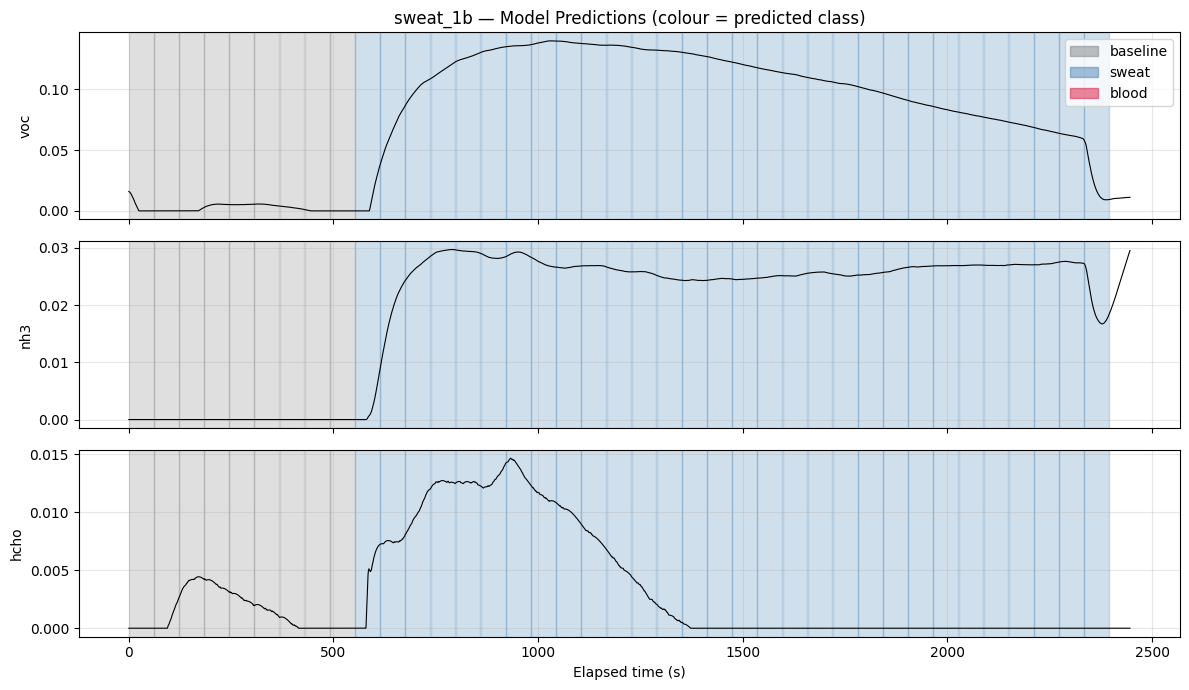

In [ ]:
classify_session("sweat_1b", "sweat_1b")


### Test — sweat_0 (Apr 04, never seen by model)

Raw CSV loaded directly — no processed pickle. Sweat tak ~2400s.

### Pipeline Helpers

`prepare_session` — loads any raw CSV through the same pipeline used for training data:
1. Resample to 1 Hz, compute `elapsed_s`
2. EMA filter on MEMS channels (optional artifact patches + zero interpolation)
3. Linear drift correction on MEMS using `baseline_window`
4. Offset correction on SPEC channels using same `baseline_window`

`classify_df` — takes a prepared DataFrame and runs the full inference pipeline:
1. Build helper columns (ROC, acc, rolling mean/std/ROC)
2. Extract 60s windows
3. Predict with `model_r2`, compute per-class probabilities
4. Print window table + plot with confidence-scaled opacity

In [ ]:
import os
import numpy as np
import matplotlib.patches as mpatches

CLASS_NAMES  = {0: "baseline", 1: "sweat", 2: "blood"}
PRED_COLORS  = {0: "grey", 1: "steelblue", 2: "crimson"}

def prepare_session(
    path: str,
    baseline_window: tuple,
    t_min: float = 0,
    t_max: float = None,
    ema_span: int = 30,
    interpolate_cols: list = [],
    artifact_windows: dict = {},
) -> pd.DataFrame:
    raw = pd.read_csv(path)
    raw["wall_time"] = pd.to_datetime(raw["wall_time"])
    df = raw.set_index("wall_time").resample("1s").first().ffill().reset_index()
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    df = df[["elapsed_s"] + CHANNELS].copy()

    if t_min > 0:
        df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] <= t_max]
    df = df.reset_index(drop=True)

    # EMA filter on MEMS
    for col in MEMS:
        s = df[col].copy().astype(float)
        if col in interpolate_cols:
            s[s == 0.0] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()
        for t0, t1 in artifact_windows.get(col, []):
            mask = (df["elapsed_s"] >= t0) & (df["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()
        df[col] = s.ewm(span=ema_span, adjust=False).mean()

    # Drift + offset correction
    t0_b, t1_b = baseline_window
    base_mask = (df["elapsed_s"] >= t0_b) & (df["elapsed_s"] <= t1_b)
    t_all = df["elapsed_s"].values

    for col in MEMS:
        t_base = df.loc[base_mask, "elapsed_s"].values
        s_base = df.loc[base_mask, col].values
        a, b = np.polyfit(t_base, s_base, deg=1)
        df[col] = (df[col] - (a * t_all + b)).clip(lower=0)

    for col in SPEC:
        offset = df.loc[base_mask, col].mean()
        df[col] = (df[col] - offset).clip(lower=0)

    print(f"Loaded: {len(df)} rows  |  {df['elapsed_s'].iloc[0]:.0f}–{df['elapsed_s'].iloc[-1]:.0f}s  |  baseline {t0_b}–{t1_b}s ({base_mask.sum()} rows)")
    return df


def classify_df(df: pd.DataFrame, title: str) -> None:
    df = df.copy()

    # Helper columns
    for col in CHANNELS:
        df[f"{col}_roc"] = df[col].diff()
        df[f"{col}_acc"] = df[f"{col}_roc"].diff()
        for w in ROLL_WINDOWS:
            df[f"{col}_roll_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
            df[f"{col}_roll_std_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
            df[f"{col}_roll_roc_{w}"]  = df[f"{col}_roc"].abs().rolling(window=w, min_periods=1).mean()

    # Window extraction
    test_windows = []
    for i in range(len(df) // WINDOW_SIZE):
        window = df.iloc[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
        feats  = extract_window_features(window, FEATURE_COLS)
        feats["t_start"] = window["elapsed_s"].iloc[0]
        feats["t_end"]   = window["elapsed_s"].iloc[-1]
        test_windows.append(feats)

    test_df_w  = pd.DataFrame(test_windows)
    preds      = model_r2.predict(test_df_w[feature_cols_r2])
    proba      = model_r2.predict_proba(test_df_w[feature_cols_r2])
    confidence = proba.max(axis=1)

    # Print
    print(f"\n{'#':>3}  {'t_start':>8}  {'t_end':>8}  {'Prediction':>12}  {'Conf':>7}  base / sweat / blood")
    print("  " + "─" * 62)
    for i, (pred, conf, prob, row) in enumerate(zip(preds, confidence, proba, test_df_w.itertuples())):
        print(f"  {i+1:>2}  {row.t_start:>8.0f}s  {row.t_end:>8.0f}s  "
              f"{CLASS_NAMES[pred]:>12}  {conf:>6.1%}  "
              f"{prob[0]:.2f} / {prob[1]:.2f} / {prob[2]:.2f}")
    print(f"\nSummary: {dict(pd.Series(preds).map(CLASS_NAMES).value_counts())}")

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for ax, col in zip(axes, MEMS):
        ax.plot(df["elapsed_s"], df[col], color="black", linewidth=0.8)
        for pred, conf, row in zip(preds, confidence, test_df_w.itertuples()):
            ax.axvspan(row.t_start, row.t_end, alpha=conf * 0.5, color=PRED_COLORS[pred])
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True, alpha=0.3)

    legend_patches = [mpatches.Patch(color=PRED_COLORS[k], alpha=0.5, label=CLASS_NAMES[k])
                      for k in sorted(PRED_COLORS)]
    axes[0].legend(handles=legend_patches, loc="upper right", fontsize=8)
    axes[0].set_title(f"{title} — predictions  (opacity = confidence)")
    axes[-1].set_xlabel("Elapsed time (s)")
    plt.tight_layout()
    plt.show()


Loaded: 4001 rows  |  0–4000s  |  baseline 500–2400s (1901 rows)

  #   t_start     t_end    Prediction     Conf  base / sweat / blood
  ──────────────────────────────────────────────────────────────
   1         0s        59s      baseline   52.0%  0.52 / 0.08 / 0.40
   2        60s       119s      baseline   63.0%  0.63 / 0.06 / 0.31
   3       120s       179s      baseline   66.0%  0.66 / 0.05 / 0.29
   4       180s       239s      baseline   87.0%  0.87 / 0.03 / 0.10
   5       240s       299s      baseline   88.0%  0.88 / 0.04 / 0.08
   6       300s       359s      baseline   96.0%  0.96 / 0.03 / 0.01
   7       360s       419s      baseline   81.0%  0.81 / 0.19 / 0.00
   8       420s       479s      baseline   80.0%  0.80 / 0.20 / 0.00
   9       480s       539s      baseline   53.0%  0.53 / 0.46 / 0.01
  10       540s       599s      baseline   57.0%  0.57 / 0.42 / 0.01
  11       600s       659s      baseline   66.0%  0.66 / 0.33 / 0.01
  12       660s       719s      baseline 

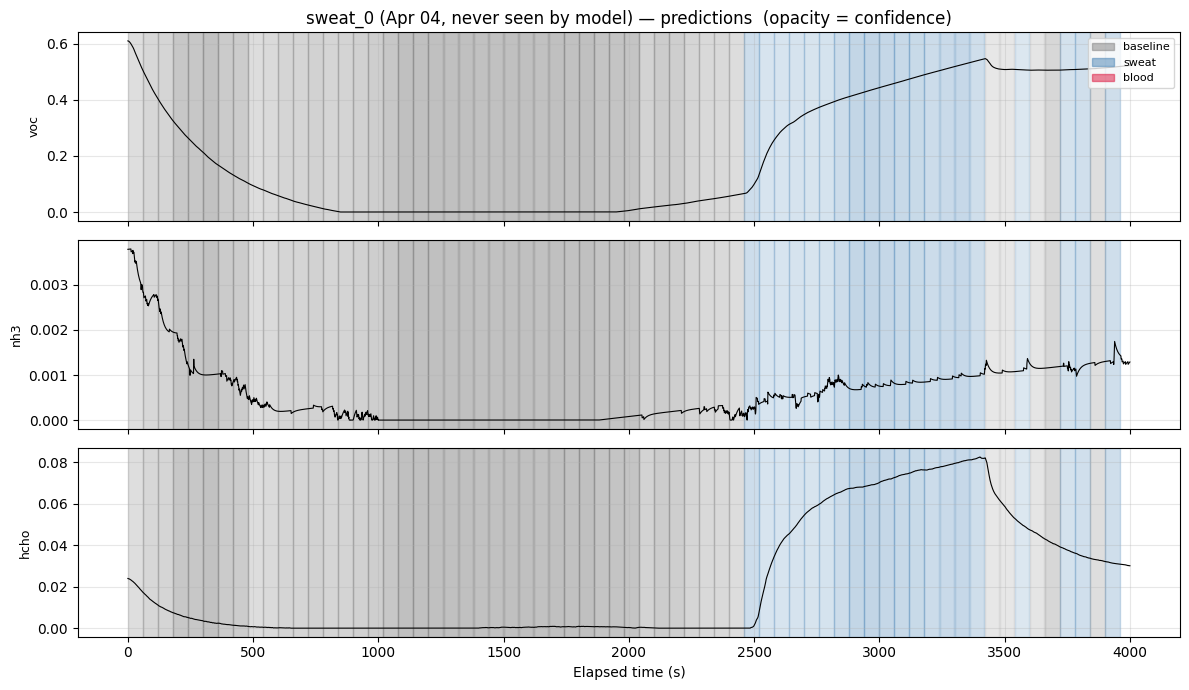

In [ ]:
df_sweat0 = prepare_session(
    path            = "../20260404-experiment/sweat.csv",
    baseline_window = (500, 2400),
    t_max           = 4000,
)
classify_df(df_sweat0, "sweat_0 (Apr 04, never seen by model)")


### Test — blood_3

In [ ]:
BLOOD_3 = "../20260421-experiment/1.5_blood_2.csv"

Loaded: 3484 rows  |  0–3483s  |  baseline 1500–1900s (401 rows)

  #   t_start     t_end    Prediction     Conf  base / sweat / blood
  ──────────────────────────────────────────────────────────────
   1         0s        59s      baseline  100.0%  1.00 / 0.00 / 0.00
   2        60s       119s      baseline  100.0%  1.00 / 0.00 / 0.00
   3       120s       179s      baseline  100.0%  1.00 / 0.00 / 0.00
   4       180s       239s      baseline  100.0%  1.00 / 0.00 / 0.00
   5       240s       299s      baseline  100.0%  1.00 / 0.00 / 0.00
   6       300s       359s      baseline   99.0%  0.99 / 0.01 / 0.00
   7       360s       419s      baseline   99.0%  0.99 / 0.01 / 0.00
   8       420s       479s      baseline   99.0%  0.99 / 0.01 / 0.00
   9       480s       539s      baseline   98.0%  0.98 / 0.02 / 0.00
  10       540s       599s      baseline   99.0%  0.99 / 0.01 / 0.00
  11       600s       659s      baseline   99.0%  0.99 / 0.01 / 0.00
  12       660s       719s      baseline 

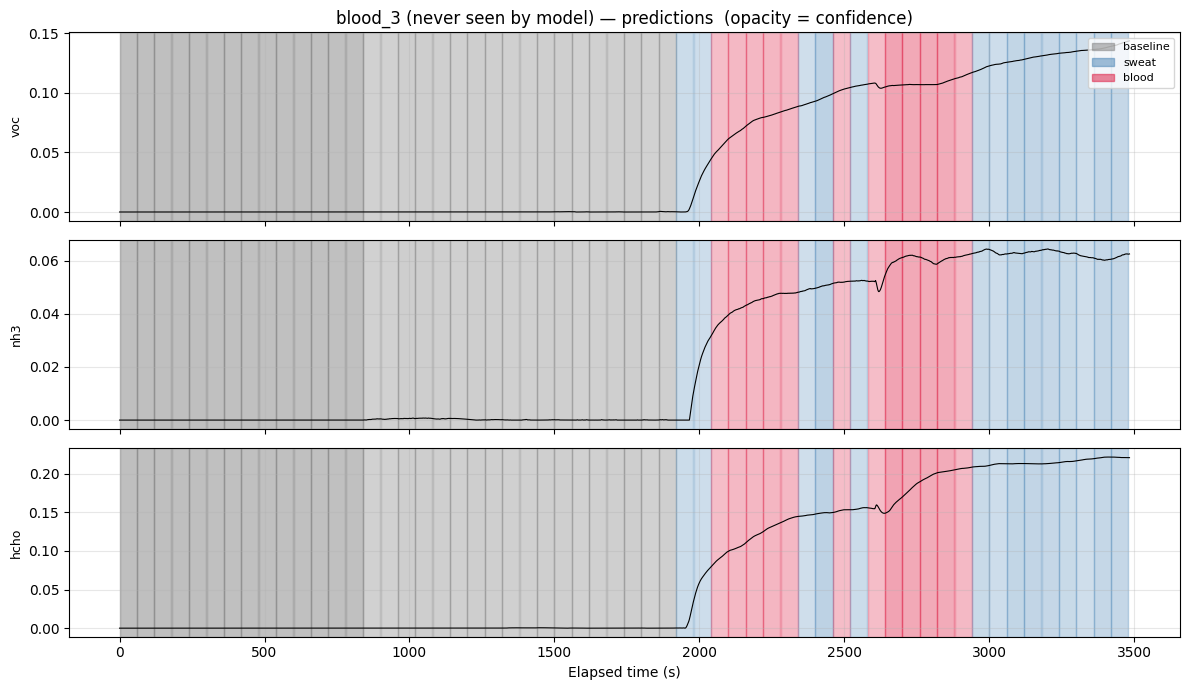

In [ ]:
df_blood3 = prepare_session(
    path            = BLOOD_3,
    baseline_window = (1500, 1900),
)
classify_df(df_blood3, "blood_3 (never seen by model)")
